In [1]:
import numpy as np
import matplotlib.pyplot as plt
import inspect
import pandas as pd
import os
from pathlib import Path
import xarray as xr
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from hypo_sleep.rec_utils import (
    get_filter_coeff,
    filter_recording,
    get_valid_times,
    resample_recording,
    reference_recording,
)
from hypo_sleep.session_helper import (
    get_spans,
    load_events,
    union_intervals,
    subtract_intervals,
)
from hypo_sleep import Session, NumpyDecoder
from hypo_sleep.pipelines.spectra_event import down_filt_ref_rec
from elephant.current_source_density import estimate_csd
from neo import AnalogSignal
import quantities as pq
import json
from spectral_connectivity import Multitaper, Connectivity, prepare_time_series
from scipy import stats
import statsmodels.api as sm

In [2]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2024-05-21_10-28-00",
            "2024-05-23_06-00-36",
            "2024-07-22_10-47-00",
            "2024-07-23_05-47-21",
            "2024-07-23_12-06-25",
            "2024-07-25_05-55-34",
            "2024-07-25_12-18-59",
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "55a4",
            "929a",
            "3ad9",
            "20a7",
            "f9f7",
            "1f25",
            "70eb",
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": [
            "HYDO01",
            "HYDO01",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO03",
            "HYDO03",
            "HYDO03",
            "HYDO04",
        ],  # "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = {
    "HYDO01": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO02": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO03": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
    "HYDO04": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
}
triggers = ["spi-peak", "so-peak", "nrem-null"]

In [3]:
tmp_animals = ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]

work_dir = Path(os.environ["WORK"])
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
session_dict = {}
animal_dict = full_dict["none"]
for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    if animal in tmp_animals:
        session_dict[date] = Session(
            config_path, animal, date, config_id, **{"base_path": "remote"}
        )

In [4]:
window = (
    3.501  # need 0.001 buffer to make sure we get the full window with time slicing
)
animals = ["HYDO01", "HYDO02", "HYDO03", "HYDO04"]
spi_traces = {
    animal: {
        date: {
            region: {filt_type: {} for filt_type in ["raw", "spi"]}
            for region in ["ctx", "hyp"]
        }
        for date, tmp_animal in zip(animal_dict["dates"], animal_dict["animal"])
        if tmp_animal == animal
    }
    for animal in animals
}  # nevents, ntimepoints, nchannels
so_traces = {
    animal: {
        date: {
            region: {filt_type: {} for filt_type in ["raw", "so"]}
            for region in ["ctx", "hyp"]
        }
        for date, tmp_animal in zip(animal_dict["dates"], animal_dict["animal"])
        if tmp_animal == animal
    }
    for animal in animals
}  # nevents, ntimepoints, nchannels
print("loading traces")

for animal, date, config_id in zip(
    animal_dict["animal"], animal_dict["dates"], animal_dict["configs"]
):
    so_df = pd.read_csv(
        Path(
            data_path,
            f"{animal}/{date}/{config_id}/slow_osc/so-df_ch-39_{config_id}.csv",
        )
    )
    spi_df = pd.read_csv(
        Path(
            data_path,
            f"{animal}/{date}/{config_id}/spindles/spindle_events_ch-39_{config_id}.csv",
        )
    )
    for region in ["ctx", "hyp"]:
        for filt_type in ["raw", "so", "spi"]:
            if filt_type == "raw":
                ref_id = (
                    "250_132b_ctx_global_fe80"
                    if region == "hyp"
                    else "250_132b_none_1da2"
                )
            elif filt_type == "so":
                ref_id = (
                    "ctx_global_fe80_so_3c1a"
                    if region == "hyp"
                    else "none_1da2_so_3c1a"
                )
            elif filt_type == "spi":
                ref_id = (
                    "ctx_global_fe80_spindle_a0a3"
                    if region == "hyp"
                    else "none_1da2_spindle_a0a3"
                )
            # ref_id = "ctx_global_fe80_so_3c1a"  # if region == "hyp" else "none_1da2")
            rec_dir = list(Path(data_path, animal, date, "rec", region).glob(ref_id))[0]
            reg_rec = si.load(rec_dir)
            if reg_rec.has_channel_location():
                reg_rec = si.depth_order(reg_rec)
            if filt_type in ["so", "raw"]:
                for ch in reg_rec.get_channel_ids():
                    ch_rec = reg_rec.select_channels(channel_ids=[ch])
                    # if ch not in so_traces[animal][date][region][filt_type].keys():
                    #     so_traces[animal][date][region][filt_type][ch] = []
                    tmp_so = []
                    for _, row in so_df.iterrows():
                        tmp_rec = ch_rec.time_slice(
                            start_time=row.neg_peak_time - window,
                            end_time=row.neg_peak_time + window,
                            # start_time=row.down_crossing - window,
                            # end_time=row.down_crossing + window,
                        )
                        tmp_so.append(
                            tmp_rec.get_traces(return_in_uV=True).flatten()[
                                : int(window * 2 * 250)
                            ]
                        )
                so_traces[animal][date][region][filt_type][ch] = np.stack(tmp_so)
            if filt_type in ["spi", "raw"]:
                for ch in reg_rec.get_channel_ids():
                    ch_rec = reg_rec.select_channels(channel_ids=[ch])
                    tmp_spi = []
                    for _, row in spi_df.iterrows():
                        tmp_rec = ch_rec.time_slice(
                            start_time=row.neg_peak - window,
                            end_time=row.neg_peak + window,
                            # start_time=row.down_crossing - window,
                            # end_time=row.down_crossing + window,
                        )
                        tmp_spi.append(
                            tmp_rec.get_traces(return_in_uV=True).flatten()[
                                : int(window * 2 * 250)
                            ]
                        )
                spi_traces[animal][date][region][filt_type][ch] = np.stack(tmp_spi)

loading traces


/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(


### EVENT EXTRACTION

In [5]:
## FOR EVENT TRIGGERS
trigger_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for date, date_dict in trigger_date_dict.items():
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            trigger_date_dict[date][trigger][region] = xr.load_dataarray(
                Path(save_path, f"{date}_{region}_{trigger}_raw_6s_1.nc"),
                engine="h5netcdf",
            )
## FOR EVENT TRIGGERS
filter_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for date, date_dict in filter_date_dict.items():
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            filter_date_dict[date][trigger][region] = xr.load_dataarray(
                Path(save_path, f"{date}_{region}_{trigger}_filt_6s_1.nc"),
                engine="h5netcdf",
            )

In [16]:
def tile_baseline(
    chunk_xr, rng, n_null_trials, n_tiles, trig_window_size, tmp_win_size
):
    chunk_times = chunk_xr.time.values
    time_concat = np.unique(
        np.concatenate(
            [
                chunk_times + i * (chunk_times[-1] - chunk_times[0])
                for i in range(n_tiles)
            ]
        )
    )
    time_concat -= (trig_window_size / 2) - (tmp_win_size / 2)
    epoch_tiles = []
    for ep_trials, (_, xr_epoch) in zip(n_null_trials, chunk_xr.groupby("epoch")):
        samp_window = rng.choice(
            xr_epoch.trial.values,
            size=(ep_trials, n_tiles),
            replace=True,
        )
        tiled_window = xr_epoch.sel(
            trial=xr.DataArray(samp_window, dims=("window", "subtrial"))
        ).transpose("window", "subtrial", "time")
        tiled_window = xr.concat(
            [
                tiled_window.isel(subtrial=0),
                *[
                    tiled_window.isel(time=slice(1, None)).isel(subtrial=t)
                    for t in range(1, tiled_window.subtrial.size)
                ],
            ],
            dim="time",
        )
        tiled_window = tiled_window.assign_coords(time=time_concat)
        new_trials = tiled_window.window.values
        da_out = (
            tiled_window.rename(window="trial")
            .drop_vars("trial")
            .assign_coords(trial=("trial", new_trials))
            .transpose("time", "trial")
        )
        assert np.all(np.diff(da_out.time.values) > 0)
        epoch_tiles.append(da_out)
    tmp_xr = xr.concat(epoch_tiles, dim="trial")
    tmp_xr = tmp_xr.assign_coords(trial=("trial", np.arange(tmp_xr.trial.size)))
    return tmp_xr

In [6]:
trig_window_size = 6.0
n_total_trials = 3000
rng = np.random.default_rng(seed=522)
filter_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for date, date_dict in filter_date_dict.items():
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            manager = session_dict[date]
            # filter_id = "low_lfp_0357"
            ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            if trigger == "nrem-null":
                filter_id = "low_lfp_0357"
            elif trigger == "so-peak":
                filter_id = "so_3c1a"
            elif trigger == "spi-peak":
                filter_id = "spindle_a0a3"
            # ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            resample_id = "250_132b"
            params = {}
            chunk_window = 1.5  # if trigger in ["so-peak", "spi-peak"] else 0.5
            spectra_window = 2 * chunk_window
            params = {
                **params,
                **manager.param_sets["reference"][ref_id],
                "reference_id": ref_id,
                **manager.param_sets["resample"][resample_id],
                "resample_id": resample_id,
                **manager.param_sets["filter"][filter_id],
                "filter_id": filter_id,
                "chunk_window": chunk_window,
                "spectra_window": spectra_window,
                "Fs": 250,
                "region": region,
                "trigger_ch": 39,
                "random_seed": 801,
            }
            region_rec = f"{region}_rec"
            rec = getattr(manager, region_rec)
            rec_duration = manager.config["data"].get("rec_duration", None)
            if "null" in trigger.split("-")[1]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans_spi = load_events["spi"](manager, channel=trigger_ch)
                valid_spans_so = load_events["so"](manager, channel=trigger_ch)
                so_times = np.stack(
                    [valid_spans_so.down_crossing, valid_spans_so.end_crossing]
                ).T
                spi_times = np.stack([valid_spans_spi.start, valid_spans_spi.end]).T
                event_intervals = union_intervals(so_times, spi_times)
                valid_spans = subtract_intervals(
                    manager.state_dict["NREM"]["times"].T, event_intervals
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            elif trigger.split("-")[0] in ["so", "spi"]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans = load_events[trigger.split("-")[0]](
                    manager, channel=params.get("trigger_ch")
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            else:
                trigger_ch_str = ""
                valid_spans = None

            rec = down_filt_ref_rec(manager, rec, rec_dur=rec_duration, **params)
            chunks = np.array(
                get_spans(manager, trigger, valid_spans=valid_spans, **params)
            )
            chunks = chunks[np.argsort(chunks[:, 0]), :]
            chunk_epoch = np.full(len(chunks), fill_value=np.nan, dtype=float)

            # chunk_epoch = {
            #     epoch_ind: np.where(
            #         (np.array([c[0] for c in chunks]) >= start)
            #         & (np.array([c[1] for c in chunks]) <= stop)
            #     )[0]
            #     for epoch_ind, (start, stop) in enumerate(
            #         manager.state_dict["NREM"]["times"].T
            #     )
            # }
            for epoch_ind, (ep_start, ep_stop) in enumerate(
                manager.state_dict["NREM"]["times"].T
            ):
                chunk_inds = np.where(
                    (np.array([c[0] for c in chunks]) >= ep_start)
                    & (np.array([c[1] for c in chunks]) <= ep_stop)
                )[0]
                chunk_epoch[chunk_inds] = epoch_ind
            time_span = (
                np.arange(
                    int(params.get("spectra_window", 3) * params.get("Fs", 250)) * 2 + 1
                )
                - int(params.get("spectra_window", 3) * params.get("Fs", 250))
            ) / params.get("Fs", 250)
            traces = []
            channels = (
                si.depth_order(rec).get_channel_ids()[::-1]
                if region == "hyp"
                else rec.get_channel_ids()
            )
            for ch in channels:
                if str(ch) in rec.get_channel_ids():
                    chunk_traces = []
                    for chunk_ind, (start, stop) in enumerate(chunks):
                        if np.isnan(chunk_epoch[chunk_ind]):
                            continue
                        if start - 0.05 < rec.get_start_time():
                            continue
                        if stop - start < params.get("spectra_window", 1):
                            if params.get("verbose", False):
                                print(
                                    f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                                )
                            continue
                        if stop + 0.05 > rec.get_end_time():
                            if params.get("verbose", False):
                                print(
                                    f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                                )
                            continue
                        tmp_rec = rec.time_slice(
                            start_time=start - 0.05,
                            end_time=stop + 0.05,
                        )
                        tmp_trace = tmp_rec.get_traces(
                            channel_ids=[ch], return_in_uV=True
                        )
                        half_arr_size = tmp_trace.flatten().size // 2
                        offset = half_arr_size - int(
                            params.get("spectra_window", 3) * params.get("Fs", 250)
                        )
                        snippet_time = tmp_rec.get_times()[offset:-offset]
                        start_ind = rec.time_to_sample_index(snippet_time[1])
                        stop_ind = rec.time_to_sample_index(snippet_time[-2])
                        for tmp_state, tmp_state_dict in manager.state_dict.items():
                            if tmp_state_dict["mask"][start_ind]:
                                start_state = tmp_state
                            if tmp_state_dict["mask"][stop_ind]:
                                stop_state = tmp_state

                        chunk_traces.append(
                            xr.DataArray.from_dict(
                                {
                                    "data": tmp_trace[offset:-offset],
                                    "dims": ["time", "trial"],
                                    "coords": {
                                        "time": {"dims": "time", "data": time_span},
                                        "trial": {
                                            "dims": "trial",
                                            "data": [chunk_ind],
                                        },
                                        "epoch": {
                                            "dims": "trial",
                                            "data": [int(chunk_epoch[chunk_ind])],
                                        },
                                    },
                                    "name": f"{ch}",
                                }
                            )
                        )
                    chunk_xr = xr.concat(chunk_traces, dim="trial")
                    # if trigger == "nrem-null":
                    #     trial_dist = np.array(
                    #         [tmp.trial.size for _, tmp in chunk_xr.groupby("epoch")]
                    #     )
                    #     tot_trials = np.sum(trial_dist)
                    #     n_null_trials = (
                    #         n_total_trials * (trial_dist / tot_trials)
                    #     ).astype(int)
                    #     chunk_times = chunk_xr.time.values
                    #     tmp_win_size = chunk_times[-1] - chunk_times[0]
                    #     n_tiles = int(np.ceil(trig_window_size / tmp_win_size))
                    #     chunk_xr = tile_baseline(
                    #         chunk_xr,
                    #         rng,
                    #         n_null_trials,
                    #         n_tiles,
                    #         trig_window_size,
                    #         tmp_win_size,
                    #     )
                    traces.append(chunk_xr)

            full_traces = xr.concat(traces, dim=pd.Index(channels, name="channel"))
            full_traces.name = f"{date}_{region}_{trigger}_filt_6s"
            epoch_file = full_traces.epoch.sortby("epoch")
            epoch_file.name = "epoch"
            epoch_file.to_netcdf(
                Path(save_path, f"{full_traces.name}_epochs_1.nc"),
                engine="h5netcdf",
            )
            ch_file = full_traces.channel
            ch_file.name = "channel"
            ch_file.to_netcdf(
                Path(save_path, f"{full_traces.name}_chs_1.nc"),
                engine="h5netcdf",
            )
            full_traces.to_netcdf(
                Path(save_path, f"{full_traces.name}_1.nc"), engine="h5netcdf"
            )
            # full_traces = full_traces.assign_coords({"epoch": ("trial", chunk_epoch)})
            filter_date_dict[date][trigger][region] = full_traces

/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: Use

In [13]:
## FOR EVENT TRIGGERS
trig_window_size = 6.0
n_total_trials = 3000
rng = np.random.default_rng(seed=522)
trigger_date_dict = {
    date: {
        trigger: {region: None for region in ["hyp", "ctx"]}
        for trigger in ["so-peak", "spi-peak", "nrem-null"]
    }
    for date in session_dict.keys()
}
save_path = Path(data_path, "lfp_traces")
save_path.mkdir(parents=True, exist_ok=True)
for date, date_dict in trigger_date_dict.items():
    for trigger, trig_dict in date_dict.items():
        for region, reg_data in trig_dict.items():
            manager = session_dict[date]
            filter_id = "low_lfp_0357"
            ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            # if filt_type == "raw":
            #     filter_id = "low_lfp_0357"
            # elif filt_type == "so":
            #     filter_id = "so_3c1a"
            # elif filt_type == "spi":
            #     filter_id = "spindle_a0a3"
            # ref_id = "ctx_global_fe80" if region == "hyp" else "none_1da2"
            resample_id = "250_132b"
            params = {}
            chunk_window = 1.5  # 1.5 if trigger in ["so-peak", "spi-peak"] else 0.5
            spectra_window = 2 * chunk_window
            params = {
                **params,
                **manager.param_sets["reference"][ref_id],
                "reference_id": ref_id,
                **manager.param_sets["resample"][resample_id],
                "resample_id": resample_id,
                **manager.param_sets["filter"][filter_id],
                "filter_id": filter_id,
                "chunk_window": chunk_window,
                "spectra_window": spectra_window,
                "Fs": 250,
                "region": region,
                "trigger_ch": 39,
                "random_seed": 801,
            }
            region_rec = f"{region}_rec"
            rec = getattr(manager, region_rec)
            rec_duration = manager.config["data"].get("rec_duration", None)
            if "null" in trigger.split("-")[1]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans_spi = load_events["spi"](manager, channel=trigger_ch)
                valid_spans_so = load_events["so"](manager, channel=trigger_ch)
                so_times = np.stack(
                    [valid_spans_so.down_crossing, valid_spans_so.end_crossing]
                ).T
                spi_times = np.stack([valid_spans_spi.start, valid_spans_spi.end]).T
                event_intervals = union_intervals(so_times, spi_times)
                valid_spans = subtract_intervals(
                    manager.state_dict["NREM"]["times"].T, event_intervals
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            elif trigger.split("-")[0] in ["so", "spi"]:
                trigger_ch = params.get(f"trigger_ch")
                valid_spans = load_events[trigger.split("-")[0]](
                    manager, channel=params.get("trigger_ch")
                )
                trigger_ch_str = f"_{int(trigger_ch):02d}"
            else:
                trigger_ch_str = ""
                valid_spans = None

            rec = down_filt_ref_rec(manager, rec, rec_dur=rec_duration, **params)
            chunks = np.array(
                get_spans(manager, trigger, valid_spans=valid_spans, **params)
            )
            chunks = chunks[np.argsort(chunks[:, 0]), :]
            chunk_epoch = np.full(len(chunks), fill_value=np.nan, dtype=float)

            # chunk_epoch = {
            #     epoch_ind: np.where(
            #         (np.array([c[0] for c in chunks]) >= start)
            #         & (np.array([c[1] for c in chunks]) <= stop)
            #     )[0]
            #     for epoch_ind, (start, stop) in enumerate(
            #         manager.state_dict["NREM"]["times"].T
            #     )
            # }
            for epoch_ind, (ep_start, ep_stop) in enumerate(
                manager.state_dict["NREM"]["times"].T
            ):
                chunk_inds = np.where(
                    (np.array([c[0] for c in chunks]) >= ep_start)
                    & (np.array([c[1] for c in chunks]) <= ep_stop)
                )[0]
                chunk_epoch[chunk_inds] = epoch_ind
            time_span = (
                np.arange(
                    int(params.get("spectra_window", 3) * params.get("Fs", 250)) * 2 + 1
                )
                - int(params.get("spectra_window", 3) * params.get("Fs", 250))
            ) / params.get("Fs", 250)
            traces = []
            channels = (
                si.depth_order(rec).get_channel_ids()[::-1]
                if region == "hyp"
                else rec.get_channel_ids()
            )
            for ch in channels:
                if str(ch) in rec.get_channel_ids():
                    chunk_traces = []
                    for chunk_ind, (start, stop) in enumerate(chunks):
                        if np.isnan(chunk_epoch[chunk_ind]):
                            continue
                        if start - 0.05 < rec.get_start_time():
                            continue
                        if stop - start < params.get("spectra_window", 1):
                            if params.get("verbose", False):
                                print(
                                    f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                                )
                            continue
                        if stop + 0.05 > rec.get_end_time():
                            if params.get("verbose", False):
                                print(
                                    f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                                )
                            continue
                        tmp_rec = rec.time_slice(
                            start_time=start - 0.05,
                            end_time=stop + 0.05,
                        )
                        tmp_trace = tmp_rec.get_traces(
                            channel_ids=[ch], return_in_uV=True
                        )
                        half_arr_size = tmp_trace.flatten().size // 2
                        offset = half_arr_size - int(
                            params.get("spectra_window", 3) * params.get("Fs", 250)
                        )
                        snippet_time = tmp_rec.get_times()[offset:-offset]
                        start_ind = rec.time_to_sample_index(snippet_time[1])
                        stop_ind = rec.time_to_sample_index(snippet_time[-2])
                        for tmp_state, tmp_state_dict in manager.state_dict.items():
                            if tmp_state_dict["mask"][start_ind]:
                                start_state = tmp_state
                            if tmp_state_dict["mask"][stop_ind]:
                                stop_state = tmp_state

                        chunk_traces.append(
                            xr.DataArray.from_dict(
                                {
                                    "data": tmp_trace[offset:-offset],
                                    "dims": ["time", "trial"],
                                    "coords": {
                                        "time": {"dims": "time", "data": time_span},
                                        "trial": {
                                            "dims": "trial",
                                            "data": [chunk_ind],
                                        },
                                        "epoch": {
                                            "dims": "trial",
                                            "data": [int(chunk_epoch[chunk_ind])],
                                        },
                                    },
                                    "name": f"{ch}",
                                }
                            )
                        )
                    chunk_xr = xr.concat(chunk_traces, dim="trial")
                    # if trigger == "nrem-null":
                    #     trial_dist = np.array(
                    #         [tmp.trial.size for _, tmp in chunk_xr.groupby("epoch")]
                    #     )
                    #     tot_trials = np.sum(trial_dist)
                    #     n_null_trials = (
                    #         n_total_trials * (trial_dist / tot_trials)
                    #     ).astype(int)
                    #     chunk_times = chunk_xr.time.values
                    #     tmp_win_size = chunk_times[-1] - chunk_times[0]
                    #     n_tiles = int(np.ceil(trig_window_size / tmp_win_size))
                    #     chunk_xr = tile_baseline(
                    #         chunk_xr,
                    #         rng,
                    #         n_null_trials,
                    #         n_tiles,
                    #         trig_window_size,
                    #         tmp_win_size,
                    #     )
                    traces.append(chunk_xr)

            full_traces = xr.concat(traces, dim=pd.Index(channels, name="channel"))
            full_traces.name = f"{date}_{region}_{trigger}_raw_6s"
            epoch_file = full_traces.epoch.sortby("epoch")
            epoch_file.name = "epoch"
            epoch_file.to_netcdf(
                Path(save_path, f"{full_traces.name}_epochs_1.nc"),
                engine="h5netcdf",
            )
            ch_file = full_traces.channel
            ch_file.name = "channel"
            ch_file.to_netcdf(
                Path(save_path, f"{full_traces.name}_chs_1.nc"),
                engine="h5netcdf",
            )
            full_traces.to_netcdf(
                Path(save_path, f"{full_traces.name}_1.nc"), engine="h5netcdf"
            )
            # full_traces = full_traces.assign_coords({"epoch": ("trial", chunk_epoch)})
            trigger_date_dict[date][trigger][region] = full_traces

# # # full_traces.get_index(["epoch", "trial"])
# epoch_file = full_traces.epoch.sortby("epoch")
# epoch_file.name = "epoch"
# epoch_file.to_netcdf(
#     Path(save_path, f"{full_traces.name}_epochs.nc"),
#     engine="h5netcdf",
# )
# ch_file = full_traces.channel
# ch_file.name = "channel"
# ch_file.to_netcdf(
#     Path(save_path, f"{full_traces.name}_chs.nc"),
#     engine="h5netcdf",
# )
# full_traces.to_netcdf(
#     Path(save_path, f"{full_traces.name}.nc"), engine="h5netcdf"
# )
# # # trigger_date_dict[date][region][trigger] = full_traces

/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.102.3 is recommended
  warnings.warn(
/gpfs01/born/user/dgramling/src/spikeinterface/src/spikeinterface/core/base.py:1117: Use

### Plot traces

In [7]:
hyp_filt_traces = {trig: [] for trig in ["so-peak", "spi-peak", "nrem-null"]}
hyp_traces = {trig: [] for trig in ["so-peak", "spi-peak", "nrem-null"]}
for date, date_dict in trigger_date_dict.items():
    # if date == "2025-02-24_09-00-29":
    #     continue
    if date not in h1_dates + h2_dates:
        continue
    for trigger, trig_dict in date_dict.items():
        tmp_key = trigger.split("-")[0]
        if tmp_key == "nrem":
            tmp_key = "raw"
        hyp_traces[trigger].append(trig_dict["hyp"].groupby("epoch").mean())
        hyp_filt_traces[trigger].append(
            filter_date_dict[date][trigger]["hyp"].groupby("epoch").mean()
        )

ValueError: must supply at least one object to concatenate

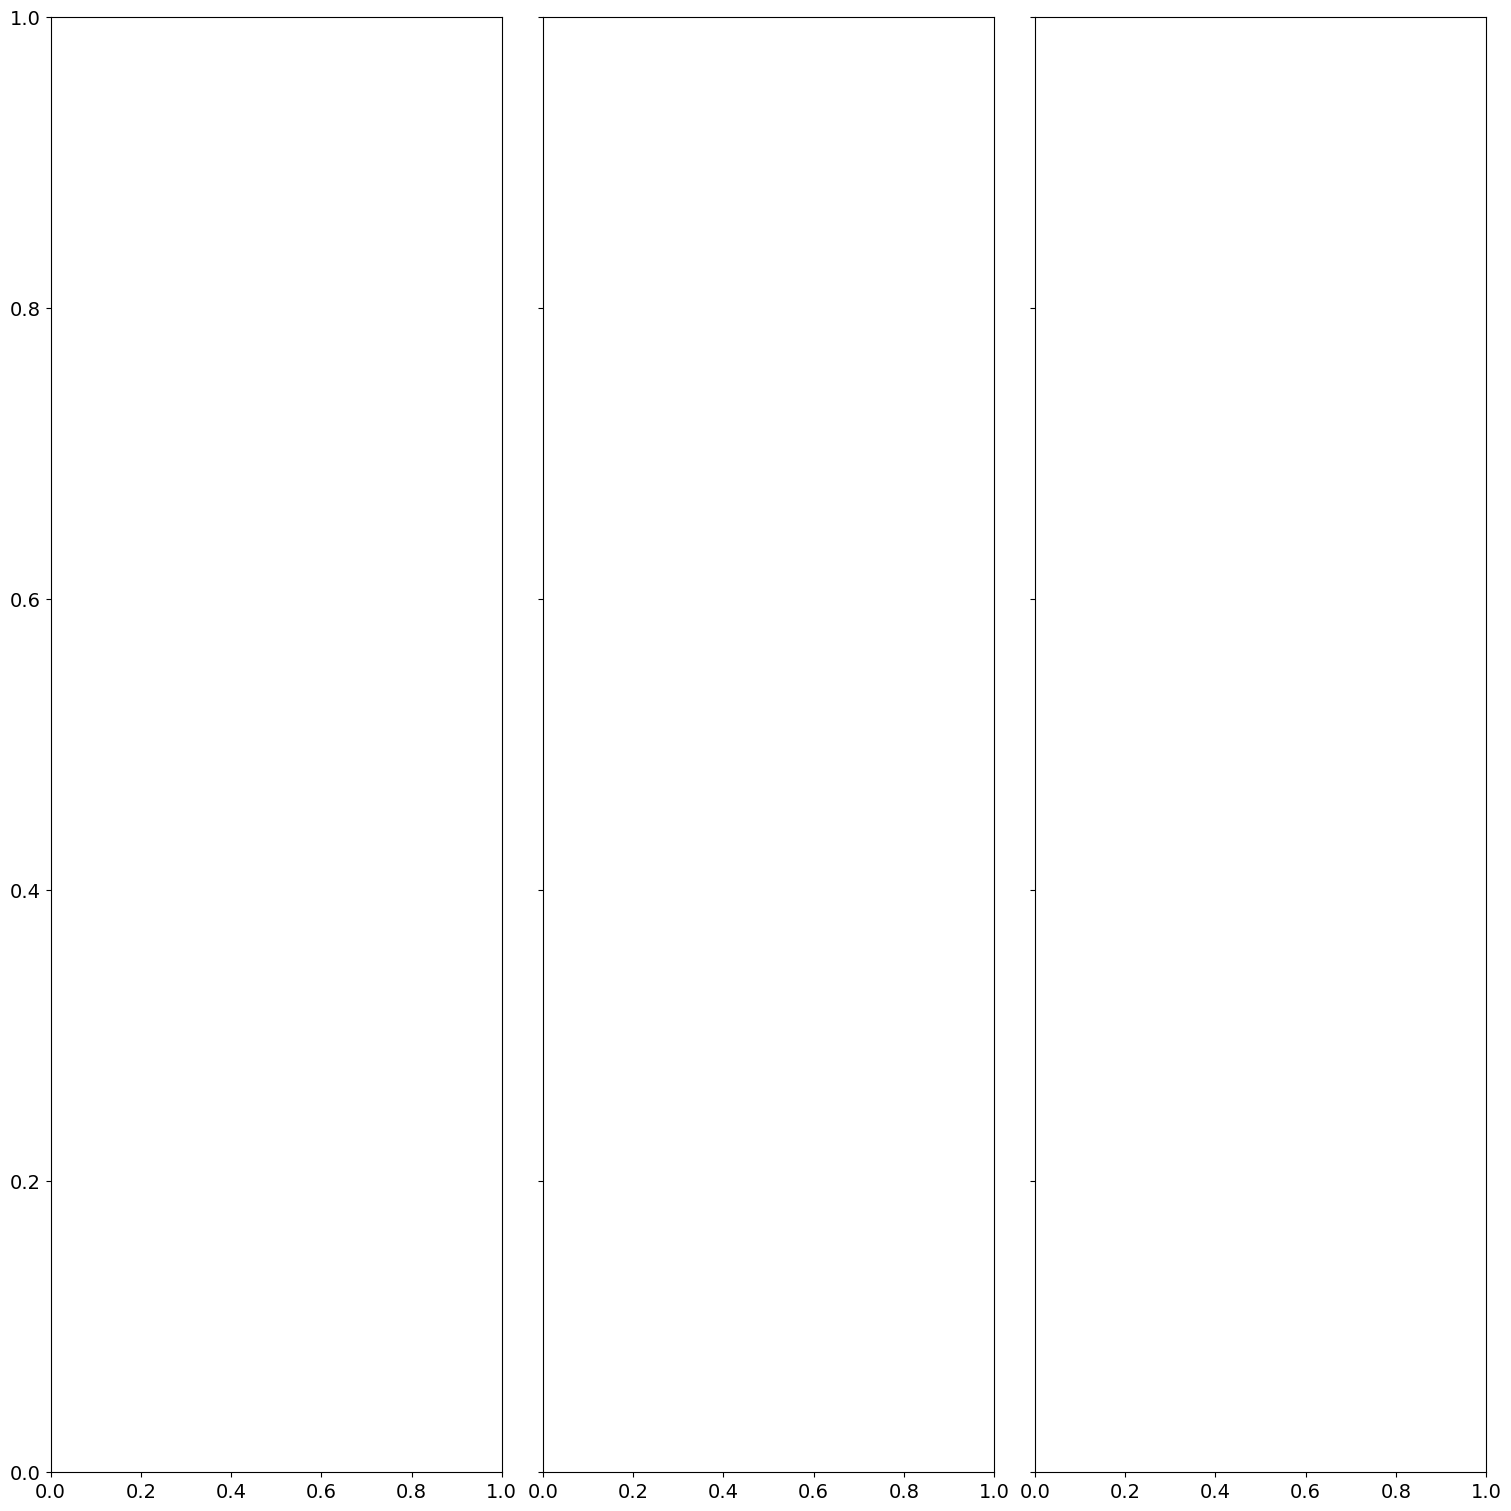

In [ ]:
tmp_animal = "HYDO01"
fig, axs = plt.subplots(
    ncols=3, figsize=(15, 15), sharex=True, sharey=True, constrained_layout=True
)
colors = plt.cm.jet(np.linspace(0, 1, len(tmp_depth_ordered)))
trig_scale = {"spi-peak": 1, "so-peak": 1, "nrem-null": 1}
for ax, (trig, data) in zip(axs.ravel(), hyp_traces.items()):
    all_traces = xr.concat(data, dim="epoch")
    for ch_ind, (ch, tmp_col) in enumerate(
        zip(all_traces.channel.values[::-1], colors)
    ):
        mean_trace = all_traces.sel(channel=ch).sel(time=slice(-2, 2)).mean(dim="epoch")
        ax.plot(
            mean_trace.time.values,
            (mean_trace.values.flatten() * trig_scale[trig]) + ch_ind * 7,
            color=tmp_col,
            lw=2,
        )
        ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{trig}")
y_tick_labels = [f"{ch}" for ch in all_traces.channel.values[::-1]]
axs[1].spines["left"].set_visible(False)
axs[1].yaxis.set_tick_params(
    bottom=False, labelbottom=False, which="major", labelsize=16
)
axs[2].yaxis.set_tick_params(
    bottom=False, labelbottom=False, which="major", labelsize=16
)
axs[2].spines["left"].set_visible(False)
_ = axs[0].set_yticks(
    ticks=np.arange(0, len(y_tick_labels) * 7, 7),
    labels=y_tick_labels,
)
axs[0].set_ylim([-10, (len(y_tick_labels) * 7) + 10])
axs[0].set_ylabel(
    "Channel ID",
    fontsize=16,
    labelpad=20,
)
fig.suptitle(f"{tmp_animal} peri-event traces", y=1.03)
fig.savefig(
    Path(
        work_dir,
        "hypo_sleep/figures",
        f"{tmp_animal}_peri-event_hyp_lfp_traces_4s.png",
    ),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)

### Coherence

In [6]:
coh_dict = {
    trig: {
        animal: {
            case: {"coherence": None, "phase": None, "frequency": None}
            for case in ["peak", "baseline"]
        }
        for animal in animals
    }
    for trig in ["so-peak", "spi-peak", "nrem-null"]
}
for date, date_dict in trigger_date_dict.items():
    # if date == "2025-02-24_09-00-29":
    #     continue
    tmp_animal = animal_dict["animal"][animal_dict["dates"].index(date)]
    for trigger, trig_dict in date_dict.items():
        xreg_data = xr.concat(
            [trig_dict["ctx"].sel(channel="39"), trig_dict["hyp"]],
            dim="channel",
        )
        epoch_coh = []
        epoch_phase = []
        epoch_freq = []
        epoch_coh_null = []
        epoch_phase_null = []
        epoch_freq_null = []
        for i_epoch, epoch_data in xreg_data.groupby("epoch"):
            peak_data = prepare_time_series(
                epoch_data.sel(time=slice(-0.5, 0.5)).transpose(
                    "time", "trial", "channel"
                )
            )
            mtm = Multitaper(
                peak_data,
                sampling_frequency=250,
                start_time=epoch_data.time.values[0],
            )
            connectivity = Connectivity.from_multitaper(mtm)
            epoch_coh.append(connectivity.coherence_magnitude())
            epoch_phase.append(connectivity.coherence_phase())
            epoch_freq.append(connectivity.frequencies)
            # coh_dict[trigger]["peak"]["coherence"].append(
            #     connectivity.coherence_magnitude()
            # )
            # coh_dict[trigger]["peak"]["phase"].append(connectivity.coherence_phase())
            # coh_dict[trigger]["peak"]["frequency"].append(connectivity.frequencies)
            baseline_data = prepare_time_series(
                epoch_data.sel(time=slice(-3.0, -2.0)).transpose(
                    "time", "trial", "channel"
                )
            )
            mtm = Multitaper(
                baseline_data,
                sampling_frequency=250,
                start_time=epoch_data.time.values[0],
            )
            connectivity = Connectivity.from_multitaper(mtm)
            epoch_coh_null.append(connectivity.coherence_magnitude())
            epoch_phase_null.append(connectivity.coherence_phase())
            epoch_freq_null.append(connectivity.frequencies)
            # coh_dict[trigger]["baseline"]["coherence"].append(
            #     connectivity.coherence_magnitude()
            # )
            # coh_dict[trigger]["baseline"]["phase"].append(
            #     connectivity.coherence_phase()
            # )
            # coh_dict[trigger]["baseline"]["frequency"].append(connectivity.frequencies)
        coh_dict[trigger][tmp_animal]["peak"]["coherence"] = np.concatenate(
            epoch_coh, axis=0
        )
        coh_dict[trigger][tmp_animal]["peak"]["phase"] = np.concatenate(
            epoch_phase, axis=0
        )
        coh_dict[trigger][tmp_animal]["peak"]["frequency"] = np.stack(epoch_freq)
        coh_dict[trigger][tmp_animal]["baseline"]["coherence"] = np.concatenate(
            epoch_coh_null, axis=0
        )
        coh_dict[trigger][tmp_animal]["baseline"]["phase"] = np.concatenate(
            epoch_phase_null, axis=0
        )
        coh_dict[trigger][tmp_animal]["baseline"]["frequency"] = np.stack(
            epoch_freq_null
        )

In [117]:
coh_df.to_csv(Path(work_dir, "hypo_sleep/processed_data", "hyp_ctx_coherence_df.csv"))

In [7]:
# Build long-form coherence table for statsmodels OLS
coh_rows = []
for trig, trig_data in coh_dict.items():
    for tmp_animal, animal_data in trig_data.items():
        for condition, cond_data in animal_data.items():
            coh = cond_data["coherence"]
            freqs = np.asarray(cond_data["frequency"])
            freqs = freqs[0] if freqs.ndim > 1 else freqs
            n_epochs, n_freqs, n_ch, _ = coh.shape
            for epoch_idx in range(n_epochs):
                for freq_idx, freq_val in enumerate(freqs):
                    for target_ch in range(1, n_ch):
                        coh_rows.append(
                            {
                                "trigger": trig,
                                "condition": condition,
                                "epoch": epoch_idx,
                                "animal": tmp_animal,
                                "frequency": float(freq_val),
                                "target_channel": target_ch,
                                "coherence": float(
                                    coh[epoch_idx, freq_idx, 0, target_ch]
                                ),
                            }
                        )
coh_df = pd.DataFrame(coh_rows)
coh_df["condition"] = pd.Categorical(
    coh_df["condition"], categories=["baseline", "peak"], ordered=True
)
coh_df["trigger"] = pd.Categorical(coh_df["trigger"])

In [ ]:
coh_df = pd.read_csv(
    Path(work_dir, "hypo_sleep/processed_data", "hyp_ctx_coherence_df.csv")
)

In [10]:
coh_df_clean = coh_df.copy()
coh_pivot = coh_df_clean.pivot_table(
    index=["epoch", "frequency", "target_channel"],
    columns="trigger",
    values="coherence",
    aggfunc="first",
).reset_index()

coh_xr = (
    xr.DataArray(
        data=coh_df_clean["coherence"].values,
        dims=["sample"],
        coords={
            "epoch": ("sample", coh_df_clean["epoch"].values),
            "frequency": ("sample", coh_df_clean["frequency"].values),
            "target_channel": ("sample", coh_df_clean["target_channel"].values),
            "trigger": ("sample", coh_df_clean["trigger"].values),
            "condition": ("sample", coh_df_clean["condition"].values),
        },
    )
    .set_index(sample=["epoch", "frequency", "target_channel", "trigger", "condition"])
    .unstack()
)

ValueError: Cannot unstack MultiIndex containing duplicates. Make sure entries are unique, e.g., by  calling ``.drop_duplicates('sample')``, before unstacking.

In [8]:
## Using Xarray Coherence Datastructure
stat_dict = {}
for trigger in ["so-peak", "spi-peak"]:
    res = stats.ttest_ind(
        coh_xr.sel(trigger=trigger, condition="peak")
        .isel(frequency=slice(0, 52))
        .mean(dim="target_channel")
        .dropna(dim="epoch"),
        coh_xr.sel(trigger=trigger, condition="baseline")
        .isel(frequency=slice(0, 52))
        .mean(dim="target_channel")
        .dropna(dim="epoch"),
        equal_var=False,
        axis=0,
    )
    orig_shape = res.pvalue.shape
    reject, corr_ps, _, _ = sm.stats.multipletests(
        res.pvalue.flatten(),
        method="bonferroni",
    )
    reject = reject.reshape(orig_shape)
    corr_ps = corr_ps.reshape(orig_shape)
    stat_dict[trigger] = {"reject": reject, "corr_pvals": corr_ps}

NameError: name 'coh_xr' is not defined

In [ ]:
## Using coh_dict directly
stat_dict = {}
for trigger in ["so-peak", "spi-peak"]:
    res = stats.ttest_ind(
        coh_dict[trigger]["peak"]["coherence"][:, :52, 0, 1:].mean(axis=-1),
        coh_dict[trigger]["baseline"]["coherence"][:, :52, 0, 1:].mean(axis=-1),
        equal_var=False,
        axis=0,
    )
    orig_shape = res.pvalue.shape
    reject, corr_ps, _, _ = sm.stats.multipletests(
        res.pvalue.flatten(),
        method="bonferroni",
    )
    reject = reject.reshape(orig_shape)
    corr_ps = corr_ps.reshape(orig_shape)
    stat_dict[trigger] = {"reject": reject, "corr_pvals": corr_ps}

(52, 32)
(52, 32)


In [ ]:
# Fit the full model with interaction
model_full = sm.formula.mixedlm(
    "coherence ~ C(condition, Treatment(reference='baseline')) * C(frequency)",
    data=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    groups=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index()["session"],
).fit()

# Fit model without interaction (main effects only)
model_no_interaction = sm.formula.mixedlm(
    "coherence ~ C(condition, Treatment(reference='baseline')) + C(frequency)",
    data=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    groups=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index()["session"],
).fit()

# Fit model with only condition (no frequency)
model_condition_only = sm.formula.mixedlm(
    "coherence ~ C(condition, Treatment(reference='baseline'))",
    data=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    groups=coh_df_session[coh_df_session["trigger"] == trigger]
    .groupby(["session", "condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index()["session"],
).fit()

# Likelihood ratio tests
lr_interaction = -2 * (model_no_interaction.llf - model_full.llf)
df_interaction = model_full.df_modelwc - model_no_interaction.df_modelwc
p_interaction = stats.chi2.sf(lr_interaction, df_interaction)

lr_condition = -2 * (model_condition_only.llf - model_no_interaction.llf)
df_condition = model_no_interaction.df_modelwc - model_condition_only.df_modelwc
p_condition = stats.chi2.sf(lr_condition, df_condition)

print(f"\n{'='*60}")
print("LIKELIHOOD RATIO TESTS")
print(f"{'='*60}")
print(f"\nCondition × Frequency Interaction:")
print(
    f"  LR statistic: {lr_interaction:.2f}, df: {df_interaction}, p-value: {p_interaction:.4e}"
)

print(f"\nMain effect of Frequency:")
print(
    f"  LR statistic: {lr_condition:.2f}, df: {df_condition}, p-value: {p_condition:.4e}"
)

print(f"\n{'='*60}")
print("COEFFICIENT TESTS FROM FULL MODEL")
print(f"{'='*60}")
print(model_full.summary())

In [37]:
freq_df

,trigger,epoch,frequency,condition,animal,coherence
112776,so-peak,0,0.0,baseline,HYDO01,0.060302
112777,so-peak,0,0.0,baseline,HYDO02,0.124951
112778,so-peak,0,0.0,baseline,HYDO03,0.114428
112779,so-peak,0,0.0,baseline,HYDO04,0.072890
112780,so-peak,0,0.0,peak,HYDO01,0.156165
...,...,...,...,...,...,...
224539,so-peak,110,0.0,baseline,HYDO04,NaN
224540,so-peak,110,0.0,peak,HYDO01,NaN
224541,so-peak,110,0.0,peak,HYDO02,NaN
224542,so-peak,110,0.0,peak,HYDO03,NaN


In [43]:
freq_df.dropna(axis=0, how="any")

,trigger,epoch,frequency,condition,animal,coherence
112776,so-peak,0,0.0,baseline,HYDO01,0.060302
112777,so-peak,0,0.0,baseline,HYDO02,0.124951
112778,so-peak,0,0.0,baseline,HYDO03,0.114428
112779,so-peak,0,0.0,baseline,HYDO04,0.072890
112780,so-peak,0,0.0,peak,HYDO01,0.156165
...,...,...,...,...,...,...
221493,so-peak,107,0.0,peak,HYDO02,0.040124
222505,so-peak,108,0.0,baseline,HYDO02,0.012102
222509,so-peak,108,0.0,peak,HYDO02,0.018651
223521,so-peak,109,0.0,baseline,HYDO02,0.049578


In [11]:
stat_res = {trig: {} for trig in ["so-peak", "spi-peak"]}
tmp_df = (
    coh_df.groupby(["trigger", "epoch", "frequency", "condition", "animal"])
    .agg({"coherence": np.nanmean})
    .reset_index()
)
freqs = coh_df[coh_df["frequency"] < 50].frequency.unique()
for trigger in ["so-peak", "spi-peak"]:
    trig_df = tmp_df[tmp_df["trigger"] == trigger]
    for tmp_freq in freqs:
        freq_df = trig_df.loc[(trig_df.frequency == tmp_freq), :].dropna(
            axis=0, how="any"
        )
        model1 = sm.formula.mixedlm(
            "coherence ~ C(condition, Treatment(reference='baseline'))",
            data=freq_df,
            # re_formula="~C(frequency)",
            groups=freq_df.animal,
        ).fit(reml=False, **{"maxiter": 5000})
        model2 = sm.formula.mixedlm(
            "coherence ~ 1",
            data=freq_df,
            groups=freq_df.animal,
        ).fit(reml=False, **{"maxiter": 5000})
        chi_sq_1_2 = 2 * (model1.llf - model2.llf)
        df_1_2 = model1.df_modelwc - model2.df_modelwc
        p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
        if p_value_1_2 < 0.05:
            model = model1
        else:
            model = model2
        stat_res[trigger][f"{tmp_freq:.02f}"] = {
            "model": model,
            "p_value": p_value_1_2,
        }

/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarni

In [ ]:
idx = pd.IndexSlice
freqs = coh_xr.frequency.sel(frequency=slice(0, 52)).values
stat_res = {}
trigger = "so-peak"
# for freq_ind, tmp_freq in enumerate(freqs):
# tmp_coh = coh_xr.sel(trigger=trigger, condition="peak").isel(frequency=freq_ind).mean(dim="target_channel").dropna(dim="epoch")
# tmp_baseline = coh_xr.sel(trigger=trigger, condition="baseline").isel(frequency=freq_ind).mean(dim="target_channel").dropna(dim="epoch")
model1 = sm.formula.mixedlm(
    "coherence ~ C(condition, Treatment(reference='baseline')) * C(frequency)",
    data=coh_df[coh_df["trigger"] == trigger]
    .groupby(["condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    re_formula="~C(frequency)",
    groups=tmp_df.animal,
).fit()  # reml=False, **{"maxiter": 5000})
model2 = sm.formula.ols(
    "coherence ~ C(condition, Treatment(reference='baseline')) + C(frequency)",
    data=coh_df[coh_df["trigger"] == trigger]
    .groupby(["condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    re_formula="~C(frequency)",
    # groups=tmp_df.animal,
).fit()  # reml=False, **{"maxiter": 5000})
model3 = sm.formula.ols(
    "coherence ~ C(condition, Treatment(reference='baseline'))",
    data=coh_df[coh_df["trigger"] == trigger]
    .groupby(["condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    re_formula="~C(frequency)",
).fit()
model4 = sm.formula.ols(
    "coherence ~ C(frequency)",
    data=coh_df[coh_df["trigger"] == trigger]
    .groupby(["condition", "frequency", "epoch"])
    .coherence.mean()
    .reset_index(),
    re_formula="~C(frequency)",
).fit()
chi_sq_1_2 = 2 * (model1.llf - model2.llf)
chi_sq_2_3 = 2 * (model2.llf - model3.llf)
# df_1_2 = model1.df_modelwc - model2.df_modelwc
# p_value_1_2 = stats.chi2.sf(chi_sq_1_2, df_1_2)
# if p_value_1_2 < 0.05:
#     model = model1
# else:
#     model = model2
# stat_res[f"{tmp_freq:.01f}"] = {
#     "model": model,
#     "p_value": p_value_1_2,
# }

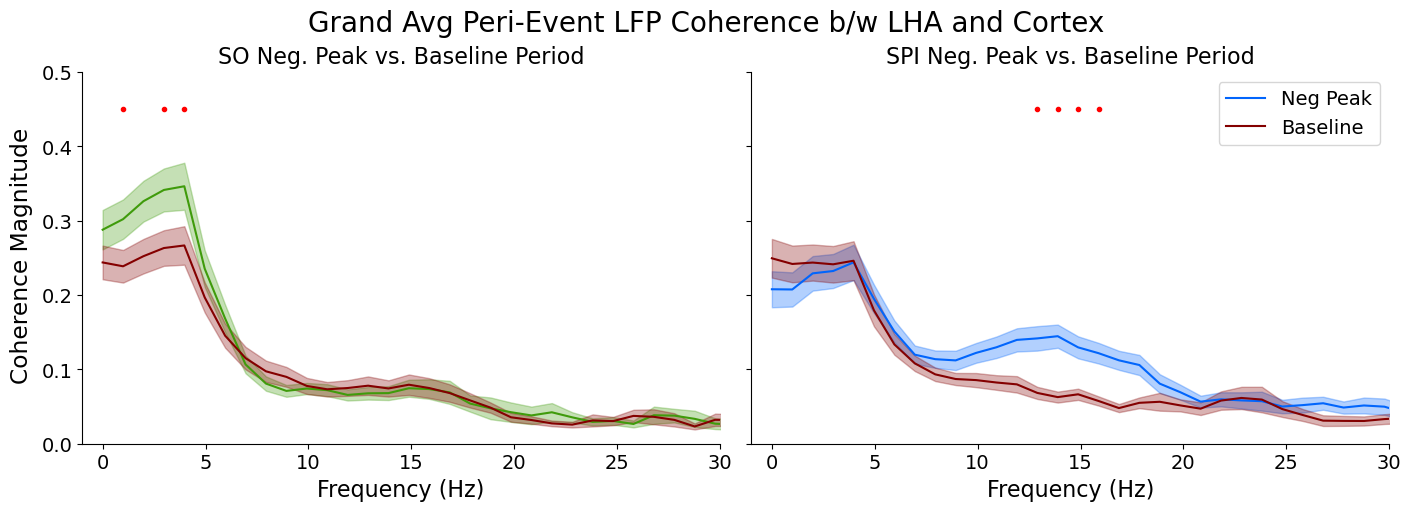

In [96]:
# trigger = "spi-peak"
freq_ind = 52
fig, axs = plt.subplots(
    ncols=2, figsize=(14, 5), sharex=True, sharey=True, constrained_layout=True
)
trig_color_dict = {"spi-peak": "#0165fc", "so-peak": "#3f9b0b", "nrem-null": "#840000"}
for ax, trigger in zip(axs.ravel(), ["so-peak", "spi-peak"]):
    tmp_freq = np.unique(coh_dict[trigger]["baseline"]["frequency"])[:freq_ind]
    ax.plot(
        tmp_freq,
        coh_dict[trigger]["peak"]["coherence"].mean(axis=0)[:freq_ind, 0, 1],
        label="Neg Peak",
        color=trig_color_dict[trigger],
    )
    ax.fill_between(
        tmp_freq,
        coh_dict[trigger]["peak"]["coherence"].mean(axis=0)[:freq_ind, 0, 1]
        - stats.sem(coh_dict[trigger]["peak"]["coherence"])[:freq_ind, 0, 1],
        coh_dict[trigger]["peak"]["coherence"].mean(axis=0)[:freq_ind, 0, 1]
        + stats.sem(coh_dict[trigger]["peak"]["coherence"])[:freq_ind, 0, 1],
        alpha=0.3,
        color=trig_color_dict[trigger],
    )

    ax.plot(
        tmp_freq,
        coh_dict[trigger]["baseline"]["coherence"].mean(axis=0)[:freq_ind, 0, 1],
        label="Baseline",
        color=trig_color_dict["nrem-null"],
    )
    ax.fill_between(
        tmp_freq,
        coh_dict[trigger]["baseline"]["coherence"].mean(axis=0)[:freq_ind, 0, 1]
        - stats.sem(coh_dict[trigger]["baseline"]["coherence"])[:freq_ind, 0, 1],
        coh_dict[trigger]["baseline"]["coherence"].mean(axis=0)[:freq_ind, 0, 1]
        + stats.sem(coh_dict[trigger]["baseline"]["coherence"])[:freq_ind, 0, 1],
        alpha=0.3,
        color=trig_color_dict["nrem-null"],
    )
    ax.set_xlim([-1, 30])
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim([0, 0.5])
    ax.set_title(f"{trigger.split('-')[0].upper()} Neg. Peak vs. Baseline Period")
    ax.scatter(
        tmp_freq[stat_dict[trigger]["reject"]],
        np.zeros_like(tmp_freq)[stat_dict[trigger]["reject"]] + 0.45,
        marker=".",
        c="r",
    )
axs[1].legend()
fig.suptitle("Grand Avg Peri-Event LFP Coherence b/w LHA and Cortex")
fig.supylabel("Coherence Magnitude")
axs[0].set_xlabel("Frequency (Hz)")
axs[1].set_xlabel("Frequency (Hz)")
fig.savefig(
    Path(work_dir, "hypo_sleep/figures", "peri-event_hyp_ctx_coherence.png"),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)

### Average traces per epoch

In [ ]:
trig_epochs = {
    trig: {"raw": [], "filt": []} for trig in ["so-peak", "spi-peak", "nrem-null"]
}
trig_var = {
    trig: {"raw": [], "filt": []} for trig in ["so-peak", "spi-peak", "nrem-null"]
}

for trig, tmp_trig in trig_epochs.items():
    for date, date_dict in trigger_date_dict.items():
        # if date in ["2025-02-24_09-00-29"]:
        #     continue

        tmp_trig["raw"].append(date_dict[trig]["hyp"].groupby("epoch").mean("trial"))
        tmp_trig["filt"].append(
            filter_date_dict[date][trig]["hyp"].groupby("epoch").mean("trial")
        )
        # trig_var[trig]["raw"].append(
        #     date_dict[trig]["hyp"].groupby("epoch").std("trial") /
        # )
        # trig_var[trig]["filt"].append(
        #     filter_date_dict[date][trig]["hyp"].groupby("epoch").std("trial")
        # )

In [9]:
tmp_date = list(trigger_date_dict.keys())[0]
tmp_depth_ordered = si.depth_order(session_dict[tmp_date].hyp_rec).get_channel_ids()
coords_1D = [
    (elem,)
    for elem in session_dict[date].hyp_rec.get_channel_locations(
        channel_ids=tmp_depth_ordered[::-1]
    )[:, 1]
]
coords_2D = [
    elem
    for elem in session_dict[date].hyp_rec.get_channel_locations(
        channel_ids=tmp_depth_ordered[::-1]
    )
]

ValueError: IDs [np.str_('15'), np.str_('14')] are not ids of the extractor. 
Available ids are ['26' '31' '9' '8' '25' '24' '23' '22' '7' '27' '6' '0' '1' '16' '2' '17'
 '3' '18' '4' '19' '10' '5' '20' '21' '28' '11' '29' '12' '30' '13'] with dtype <U2

In [ ]:
# coords_1D = [
#     (elem,)
#     for elem in session_dict[date].hyp_rec.get_channel_locations(
#         channel_ids=depth_ordered_chs[::-1]
#     )[:, 1]
# ]
# coords_2D = [
#     elem
#     for elem in session_dict[date].hyp_rec.get_channel_locations(
#         channel_ids=depth_ordered_chs[::-1]
#     )
# ]
# trig_csd = {"1D": {}, "2D": {}}
# for trig, data in trig_epochs.items():
#     concat_data = xr.concat(data, dim="epoch")
#     csd_1D_list = []
#     csd_2D_list = []
#     for e_ind, epoch in enumerate(concat_data.epoch.values):
#         tmp_data = concat_data.isel(epoch=e_ind)
#         # tmp_data = xr.concat(data, dim="epoch")

#         trig_sig = AnalogSignal(
#             tmp_data.to_numpy().T, units="uV", sampling_rate=250 * pq.Hz
#         )
#         ## 1D CSD
#         trig_sig.annotate(coordinates=coords_1D * pq.um)
#         csd_1D = estimate_csd(
#             trig_sig,
#             method="KCSD1D",
#             **{
#                 # "xmin": 0,
#                 # "xmax": 60,
#                 # "ymin": 0,
#                 # "ymax": 775,
#                 # "gdx": 1.2,
#                 # "gdy": 25,
#                 "n_src_init": 2000,
#                 # "lambd": 0.001,
#             },
#         )
#         csd_1D_list.append(csd_1D)
#         # trig_csd["1D"][trig] = csd_1D

#         ## 2D CSD
#         trig_sig = AnalogSignal(
#             tmp_data.to_numpy().T,
#             units="uV",
#             sampling_rate=250 * pq.Hz,
#         )
#         trig_sig.annotate(coordinates=coords_2D * pq.um)
#         csd_2D = estimate_csd(
#             trig_sig,
#             method="KCSD2D",
#             **{
#                 # "xmin": 0,
#                 # "xmax": 0.06,
#                 # "ymin": 0,
#                 # "ymax": 0.775,
#                 # "gdx": 1.2,
#                 # "gdy": 12,
#                 "n_src_init": 2000,
#                 # "lambd": 0.001,
#             },
#         )
#         csd_2D_list.append(csd_2D)
#         # trig_csd["2D"][trig] = csd_2D
#     trig_csd["1D"][trig] = csd_1D_list
#     trig_csd["2D"][trig] = csd_2D_list
#     print(f"Completed CSD for trigger: {trig}")

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.00012115276586285876
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.00012115276586285876
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cr

In [11]:
for trig, data in trig_epochs.items():
    tmp_data = xr.concat(data["filt"], dim="epoch")
    print(tmp_data.shape)
    tmp_data.name = f"{trig}_hyp"
    tmp_data.to_netcdf(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces/",
            f"HYDO01-2_{trig}_hyp_traces_filt_6s.nc",
        ),
        engine="h5netcdf",
    )
    tmp_data = xr.concat(data["raw"], dim="epoch")
    print(tmp_data.shape)
    tmp_data.name = f"{trig}_hyp"
    tmp_data.to_netcdf(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces/",
            f"HYDO01-2_{trig}_hyp_traces_raw_6s.nc",
        ),
        engine="h5netcdf",
    )

(32, 1501, 700)
(32, 1501, 700)
(32, 1501, 676)
(32, 1501, 676)
(32, 1501, 699)
(32, 1501, 699)


##### Load epoch traces per event

In [117]:
trig_epochs = {trig: {"raw": None} for trig in ["so-peak", "spi-peak", "nrem-null"]}
for trig in trig_epochs.keys():
    trig_epochs[trig]["raw"] = xr.load_dataarray(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces/",
            f"{trig}_hyp_traces_raw_6s.nc",
        ),
        engine="h5netcdf",
    )
    trig_epochs[trig]["filt"] = xr.load_dataarray(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces/",
            f"{trig}_hyp_traces_filt_6s.nc",
        ),
        engine="h5netcdf",
    )

In [12]:
channel_locations = np.load(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces/hyp_ch3_locs_csd.npy",
    )
)

#### Run Coherence

##### Load Cortical LFP

In [13]:
lfp_load_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/lfp_traces")
triggers = ["so-peak", "spi-peak", "nrem-null"]
dates_to_use = [
    date
    for date, animal in zip(full_dict["none"]["dates"], full_dict["none"]["animal"])
    if animal in tmp_animals
]
lfp_data_dict = {
    date: {reg: {trig: None for trig in triggers} for reg in ["hyp", "ctx"]}
    for date in dates_to_use
}
for date, date_data in lfp_data_dict.items():
    for region, reg_data in date_data.items():
        for trig, trig_data in reg_data.items():
            filename = f"{date}_{region}_{trig}_raw_6s_1.nc"
            tmp = xr.load_dataarray(Path(lfp_load_path, filename), engine="h5netcdf")
            tmp = tmp.assign_coords(
                time=np.array(
                    [np.timedelta64(int(val * 1e9), "ns") for val in tmp.time.values]
                )
            )
            lfp_data_dict[date][region][trig] = tmp
re_lfp_data_dict = {
    animal: {reg: {trig: [] for trig in triggers} for reg in ["hyp", "ctx"]}
    for animal in tmp_animals
}
for date, date_data in lfp_data_dict.items():
    animal = [
        animal
        for animal, tmp_date in zip(
            full_dict["none"]["animal"], full_dict["none"]["dates"]
        )
        if tmp_date == date
    ][0]
    for region, reg_data in date_data.items():
        for trig, trig_data in reg_data.items():
            re_lfp_data_dict[animal][region][trig].append(
                trig_data.groupby("epoch").mean(dim="trial")
            )

#### Run CSD

In [ ]:
coords_1D = [(elem,) for elem in channel_locations[:, 1]]
coords_2D = [elem for elem in channel_locations]
trig_csd = {"1D": {}, "2D": {}}
trigs_to_run = ["nrem-null", "so-peak", "spi-peak"]
save_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/csd/")
time_slice = slice(np.timedelta64(-1.5, "s"), np.timedelta64(1.5, "s"))
for trig, data in trig_epochs.items():
    load_1D = False
    load_2D = False
    # tmp_data = xr.concat(data, dim="epoch").mean(dim="epoch")
    # if Path(save_path, f"csd_1D_{trig}.nc").exists():
    #     load_csd = xr.load_dataarray(
    #         Path(save_path, f"csd_1D_{trig}.nc"), engine="h5netcdf"
    #     )
    #     trig_csd["1D"][trig] = load_csd
    #     load_1D = True
    # if Path(save_path, f"csd_2D_{trig}.nc").exists():
    #     load_csd = xr.load_dataarray(
    #         Path(save_path, f"csd_2D_{trig}.nc"), engine="h5netcdf"
    #     )
    #     trig_csd["2D"][trig] = load_csd
    #     load_2D = True
    if load_1D and load_2D:
        continue
    print(f"running CSD for trigger: {trig}")
    if isinstance(data["raw"], list):
        concat_data = xr.concat(data["raw"], dim="epoch")
    else:
        concat_data = data["raw"]
    concat_data = concat_data.assign_coords(
        {"epoch": np.arange(concat_data.sizes["epoch"])}
    )
    tmp_data = concat_data.assign_coords({"time": pd.TimedeltaIndex(time_index)})
    tmp_data.resample(time="20ms").mean()
    tmp_data = tmp_data.sel(time=time_slice)
    # tmp_data = tmp_data.rolling(time=3).mean().isel(time=slice(2, None))
    # csd_1D_time = []
    # for t in tmp_data.time.values:
    #     ## 1D CSD
    #     trig_sig = AnalogSignal(
    #         tmp_data.sel(time=t).to_numpy()[:, np.newaxis].T,
    #         units="uV",
    #         sampling_rate=250 * pq.Hz,
    #     )
    #     trig_sig.annotate(coordinates=coords_1D * pq.um)
    #     csd_1D, _ = estimate_csd(
    #         trig_sig,
    #         method="KCSD1D",
    #         **{
    #             # "xmin": -0.025,
    #             # "xmax": 0.1,
    #             # "gdx": 0.005,
    #             "xmin": -0.1,
    #             "xmax": 0.850,
    #             "gdx": 0.005,
    #             # "gdy": 12,
    #             "n_src_init": 1000,
    #             "R_init": 0.05,
    #             # "lambd": 0.01,
    #             # "lambdas": np.arange(0.001, 0.1, 0.005),
    #         },
    #     )
    #     coords_1D_out = csd_1D.annotations["x_coords"]
    #     csd_1D_time.append(np.array(csd_1D))
    # csd_1D_xr = xr.DataArray(
    #     data=np.concatenate(csd_1D_time),
    #     dims=["time", "y"],
    #     coords={"time": tmp_data.time.values, "y": coords_1D_out},
    # )
    # trig_csd["1D"][trig] = csd_1D_xr
    # csd_1D_xr.to_netcdf(
    #     Path(
    #         "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/csd/",
    #         f"csd_1D_{trig}_6s_smooth.nc",
    #     ),
    #     engine="h5netcdf",
    # )
    csd_2D_epoch = []
    for epoch in tmp_data.epoch.values:
        print(f"\n----------------- epoch {epoch:02d} -----------------\n")
        epoch_data = tmp_data.sel(epoch=epoch)
        csd_2D_time = []
        for t in tmp_data.time.values:
            ## 2D CSD
            trig_sig = AnalogSignal(
                epoch_data.sel(time=t).to_numpy()[:, np.newaxis].T,
                units="uV",
                sampling_rate=250 * pq.Hz,
            )
            trig_sig.annotate(coordinates=coords_2D * pq.um)
            csd_2D, k = estimate_csd(
                trig_sig,
                method="KCSD2D",
                coordinates=coords_2D * pq.um,
                # process_estimate=True,
                **{
                    "xmin": -0.025,
                    "xmax": 0.1,
                    "gdx": 0.005,
                    "ymin": -0.1,
                    "ymax": 0.850,
                    "gdy": 0.005,
                    # "gdy": 12,
                    "n_src_init": 1000,
                    "R_init": 0.05,
                    # "lambd": 0.01,
                    # "lambdas": np.arange(0.001, 0.1, 0.005),
                },
            )
            x_coords = csd_2D.annotations["x_coords"][:, 0]
            y_coords = csd_2D.annotations["y_coords"][0, :]
            csd_2D_time.append(np.array(csd_2D).squeeze().astype(np.float32))
        csd_2D_epoch.append(np.stack(csd_2D_time))
    csd_2D_xr = xr.DataArray(
        data=np.concatenate(csd_2D_epoch),
        dims=["time", "x", "y"],
        coords={"time": tmp_data.time.values, "x": x_coords, "y": y_coords},
    )
    # trig_csd["2D"][trig] = csd_2D_xr.astype(np.float32)
    csd_2D_xr.to_netcdf(
        Path(
            "/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/csd/",
            f"csd_2D_{trig}_6s_smooth.nc",
        ),
        engine="h5netcdf",
    )
    break
    print(f"----------completed & saved CSD for {trig}------------")

running CSD for trigger: so-peak

----------------- epoch 00 -----------------

No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 0.05 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.05
R, lambda : 

#### Load CSD

In [13]:
tmp_animal = "HYDO04"
work_dir = os.environ["WORK"]
csd_save_path = Path(work_dir, "hypo_sleep/processed_data/csd/")
trig_csd = {"1D": {}, "2D": {}}
for trig in ["so-peak", "spi-peak", "nrem-null"]:
    trig_csd["2D"][trig] = xr.load_dataarray(
        Path(
            csd_save_path,
            # f"csd_2D_{trig}_epoch_test_20ms_no15_filt_time_4s.nc",
            f"{tmp_animal}_csd_2D_{trig}_epoch_test_20ms_time_4s.nc",
        ),
        engine="h5netcdf",
    )

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/csd/HYDO04_csd_2D_so-peak_epoch_test_20ms_time_4s.nc', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [17]:
tmp_depth_ordered = depth_ordered_chs[tmp_animal]

so-peak: 145
spi-peak: 144
nrem-null: 149


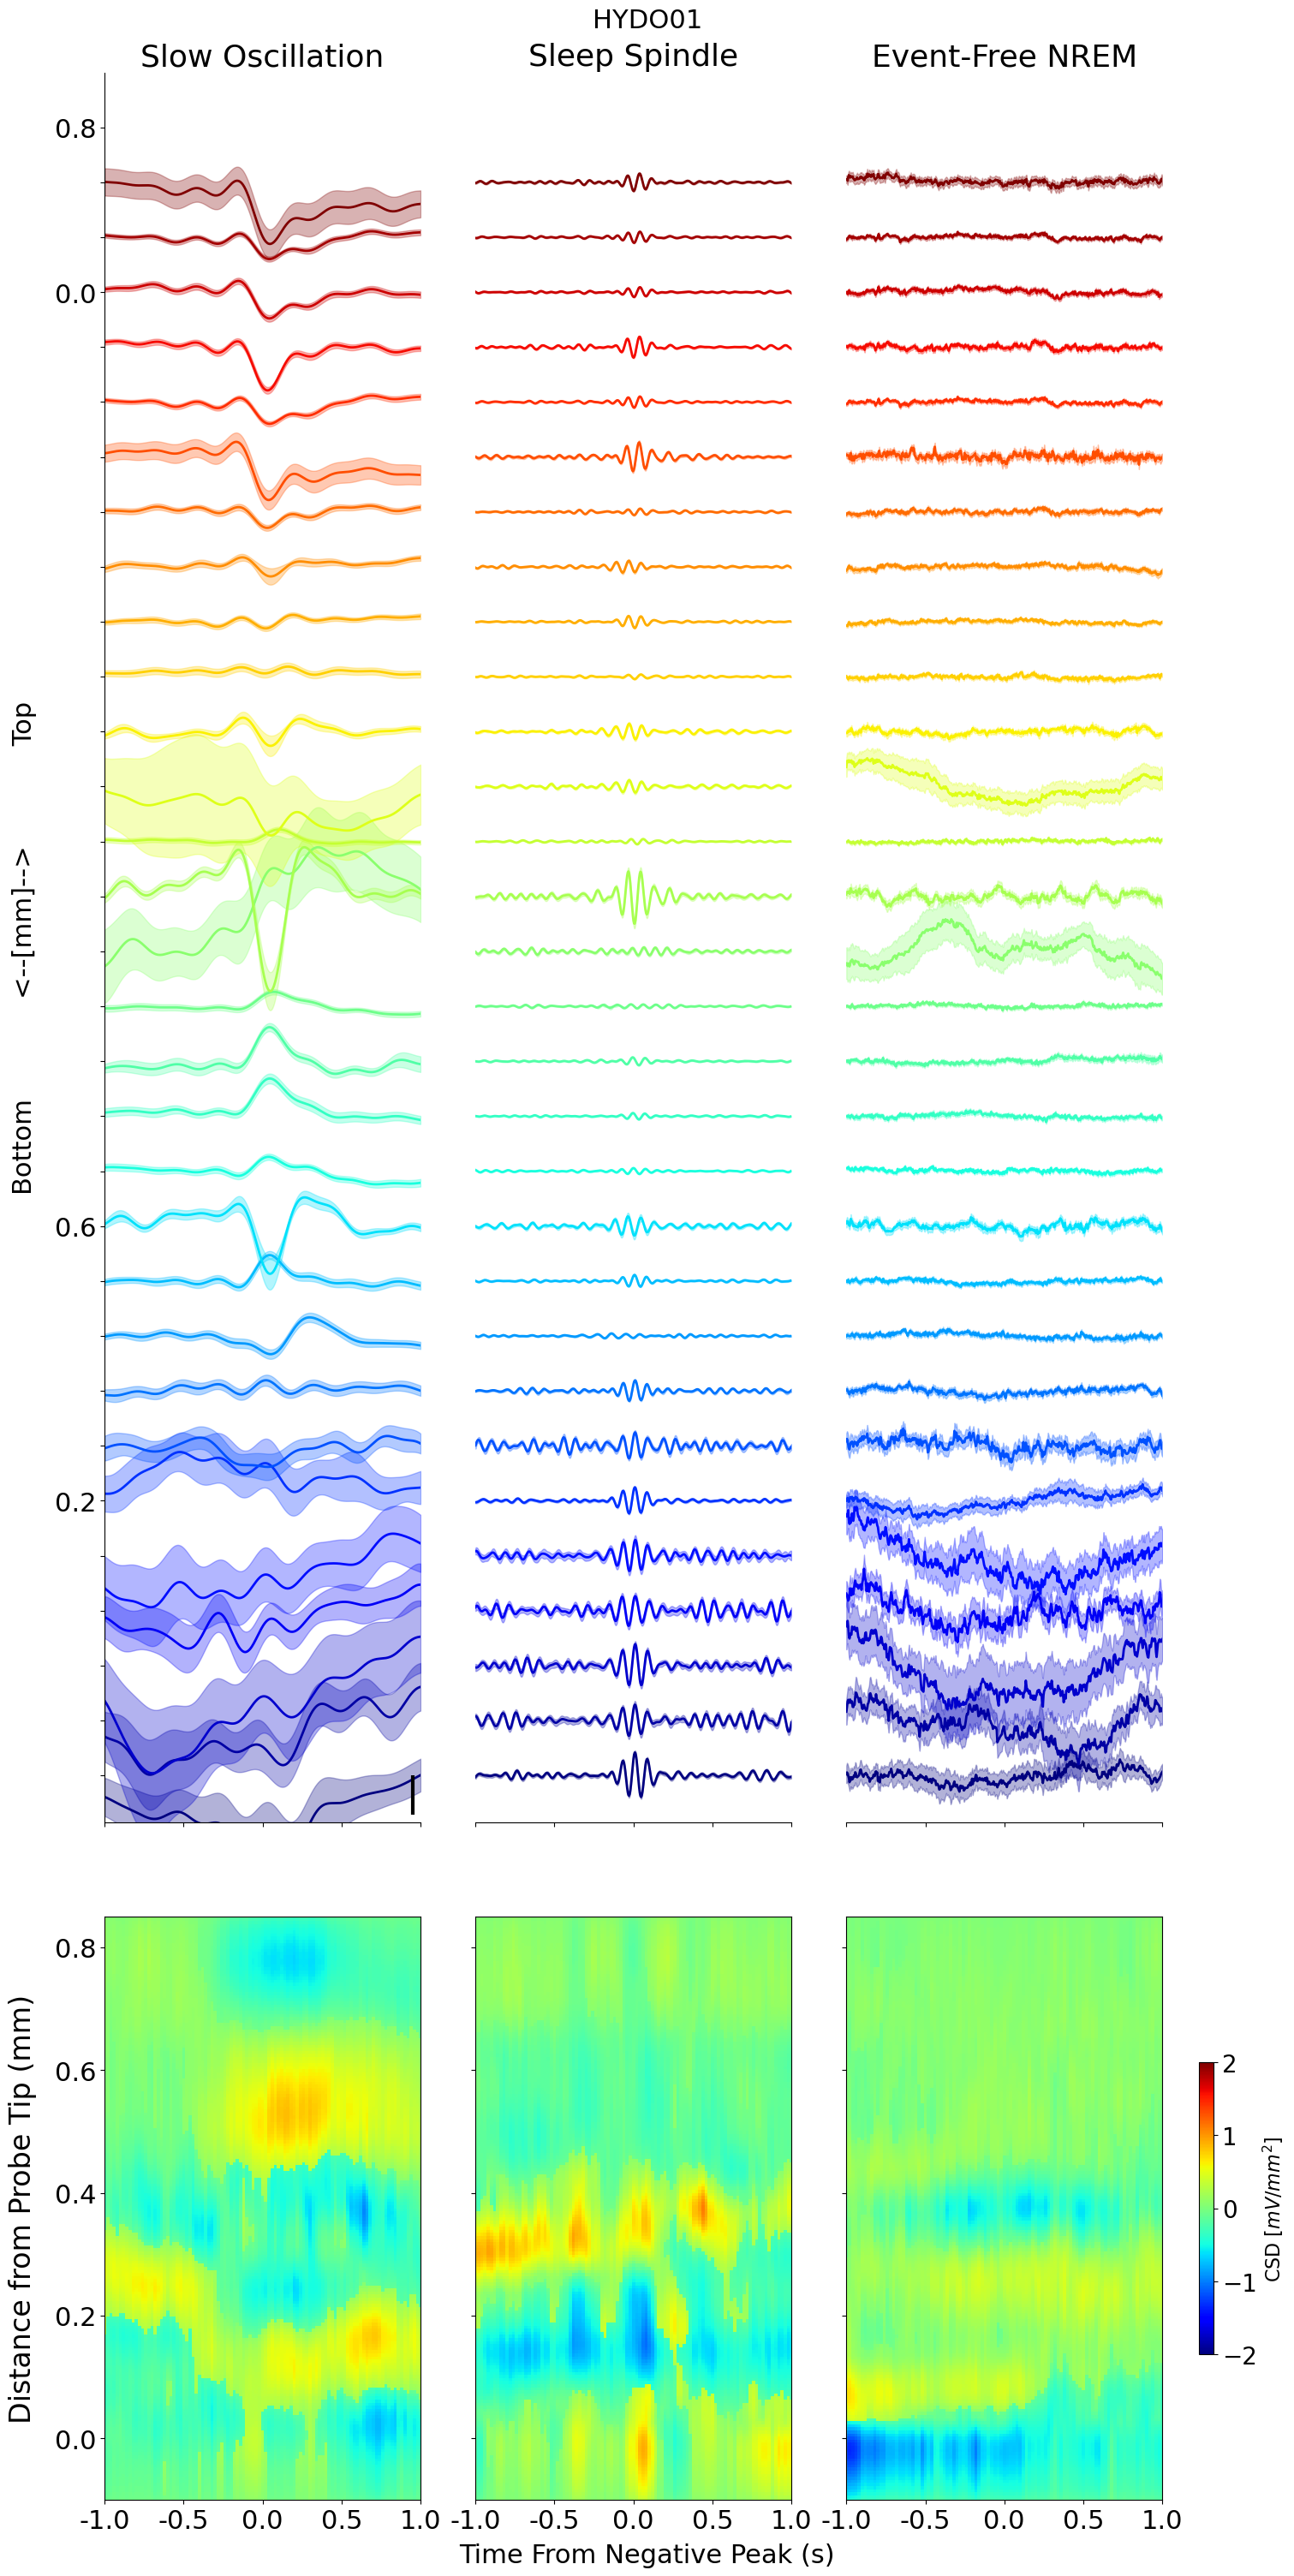

In [25]:
save = True
title_dict = {
    "so-peak": "Slow Oscillation",
    "spi-peak": "Sleep Spindle",
    "nrem-null": "Event-Free NREM",
}
fig, axs = plt.subplots(
    ncols=3,
    nrows=2,
    figsize=(15, 30),
    height_ratios=[24, 8],  # [24, 1, 8],
    sharex=True,
    sharey="row",
    constrained_layout=True,
)
time_slice = slice(-1, 1)
colors = plt.cm.jet(np.linspace(0, 1, len(tmp_depth_ordered)))
trig_scale = {"spi-peak": 1, "so-peak": 1, "nrem-null": 1}
for ax, (trig, data) in zip(axs[0, :].ravel(), trig_epochs.items()):
    all_traces = xr.concat(data["filt"], dim="epoch")
    # all_traces = data["filt"]
    print(f"{trig}: {all_traces.epoch.size}")
    for ch_ind, (ch, tmp_col) in enumerate(
        zip(all_traces.channel.values[::-1], colors)
    ):
        mean_trace = all_traces.sel(channel=ch).sel(time=time_slice).mean(dim="epoch")
        mean_var = all_traces.sel(channel=ch).sel(time=time_slice).std(
            dim="epoch"
        ) / np.sqrt(all_traces.sel(channel=ch).sel(time=time_slice).epoch.size)
        ax.plot(
            mean_trace.time.values,
            (mean_trace.values.flatten() * trig_scale[trig]) + ch_ind * 7,
            color=tmp_col,
            lw=2,
        )
        ax.fill_between(
            mean_trace.time.values,
            ((mean_trace.values.flatten() - mean_var) * trig_scale[trig]) + ch_ind * 7,
            ((mean_trace.values.flatten() + mean_var) * trig_scale[trig]) + ch_ind * 7,
            color=tmp_col,
            alpha=0.3,
        )
        ax.spines[["top", "right"]].set_visible(False)
    ax.plot(
        mean_trace.time.values,
        np.full_like(mean_trace.time.values, np.nan),
        color=tmp_col,
        lw=2,
    )
    ax.set_title(f"{title_dict[trig]}", fontsize=26)
# y_tick_labels = [f"{ch}" for ch in all_traces.channel.values[::-1]]
axs[0, 0].vlines(0.95, ymin=-5, ymax=0, colors="k", lw=3)
y_tick_labels = [
    *[
        f"{ch}" if ch in [0.0, 0.2, 0.4, 0.6] else " "
        for ch in (channel_locations[:, 1][::-1] * 0.001)
    ],
    "0.8",
]

_ = axs[0, 0].set_yticks(
    ticks=np.arange(0, len(y_tick_labels) * 7, 7),
    labels=y_tick_labels,
)
for ax in axs[0, :].ravel():
    ax.tick_params(axis="y", labelsize=22)
axs[0, 1].spines["left"].set_visible(False)
axs[0, 1].yaxis.set_tick_params(
    bottom=False, labelbottom=False, which="major", labelsize=18
)
axs[0, 2].yaxis.set_tick_params(
    bottom=False, labelbottom=False, which="major", labelsize=18
)
axs[0, 2].spines["left"].set_visible(False)
# _ = axs[0, 0].set_yticks(
#     ticks=np.arange(0, len(y_tick_labels) * 7, 7),
#     labels=y_tick_labels,
# )
axs[0, 0].set_ylim([-6, (len(y_tick_labels) * 7)])
axs[0, 0].set_ylabel(
    "Bottom            <--[mm]-->            Top",
    fontsize=22,
    labelpad=15,
)
trig_scale = {
    "so-peak": 1,
    "spi-peak": 1,
    "nrem-null": 1,
}
# fig.subplots_adjust(hspace=0.2)
colors = plt.cm.jet(np.linspace(0, 1, len(tmp_depth_ordered)))
csd_slice = slice(
    np.timedelta64(time_slice.start * 1000, "ms"),
    np.timedelta64(time_slice.stop * 1000, "ms"),
)
Fs = 50
csd_ax = 1
for ax, (trig, tmp_csd) in zip(axs[csd_ax, :].ravel(), trig_csd["2D"].items()):
    tmp_csd = tmp_csd.sel(time=csd_slice).mean(dim="epoch")
    n_time = tmp_csd.shape[0]
    tmp_time = (np.arange(n_time) - int(n_time // 2)) / Fs
    tmp_csd = tmp_csd.astype(np.float32)
    # tmp_time = (np.arange(n_time) - int((n_time // 5) * 3)) / 250
    x_val_list = np.stack(
        [
            xr.where(
                (
                    xr.ufuncs.abs(tmp_csd.sel(y=tmp_y).max(dim="x"))
                    >= xr.ufuncs.abs(tmp_csd.sel(y=tmp_y).min(dim="x"))
                ),
                tmp_csd.sel(y=tmp_y).max(dim="x"),
                tmp_csd.sel(y=tmp_y).min(dim="x"),
            ).values
            for tmp_y in tmp_csd.y.values
        ]
    )
    x_vals = xr.DataArray.from_dict(
        {
            "data": x_val_list.T,
            "coords": {
                "time": {"dims": "time", "data": tmp_csd.time.values},
                "y": {"dims": "y", "data": tmp_csd.y.values},
            },
            "dims": ["time", "y"],
        }
    )
    h1 = ax.pcolormesh(
        tmp_time,
        tmp_csd.y.values * pq.mm,
        # tmp_csd.mean(axis=1).T,
        x_vals.T,
        # tmp_csd.max(dim="x").T - xr.ufuncs.abs(tmp_csd.min(dim="x").T) #- tmp_csd.sel(time=time_slice).mean(dim=["time", "x"]).T,
        # aspect="auto",
        # extent=[0, n_time, 0, 775],
        vmin=-2.0,
        vmax=2.0,
        cmap="jet",
    )
    # ax.set_xticks(
    #     (np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
    #     labels=(np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
    # )
    ax.set_xticks(
        ((np.arange(0, n_time + 1, int(Fs // 2)) - int(n_time // 2)) / Fs),
        labels=(np.arange(0, n_time + 1, int(Fs // 2)) - int(n_time // 2)) / Fs,
    )
    # ax.set_title(f"{trig.split("-")[0].upper()} Grand Avg")
cbar = fig.colorbar(
    h1,
    ax=axs[csd_ax, -1],
    shrink=0.5,
    label=f"CSD [$mV/mm^{2}$]",  # ticks=[-0.3, -0.15, 0.0, 0.15, 0.3]
)
cbar.ax.tick_params(labelsize=20)
# axs[1].set_xlabel("time from negative peak (s)")
for ax in axs[csd_ax, :].ravel():
    ax.tick_params(axis="both", labelsize=22)
axs[csd_ax, 0].set_xlim([time_slice.start, time_slice.stop])
# print(axs[0].get_ylim())
axs[csd_ax, 0].set_ylim([-0.1, 0.85])
axs[csd_ax, 0].set_ylabel("Distance from Probe Tip (mm)", fontsize=24, labelpad=15)
# for ax in axs[1, :].ravel():
#     ax.axis("off")
fig.supxlabel("Time From Negative Peak (s)", fontsize=22)
fig.get_layout_engine().set(
    h_pad=4 / 72,
    hspace=0.07,
)
fig.suptitle(f"{tmp_animal}", fontsize=22)
if save:
    fig.savefig(
        Path(
            work_dir,
            "hypo_sleep/figures",
            f"{tmp_animal}_csd_2D_hyp_lfp_filt_traces_2s_pos_neg_sem.png",
        ),
        dpi=500,
        facecolor="white",
        transparent=False,
        bbox_inches="tight",
    )

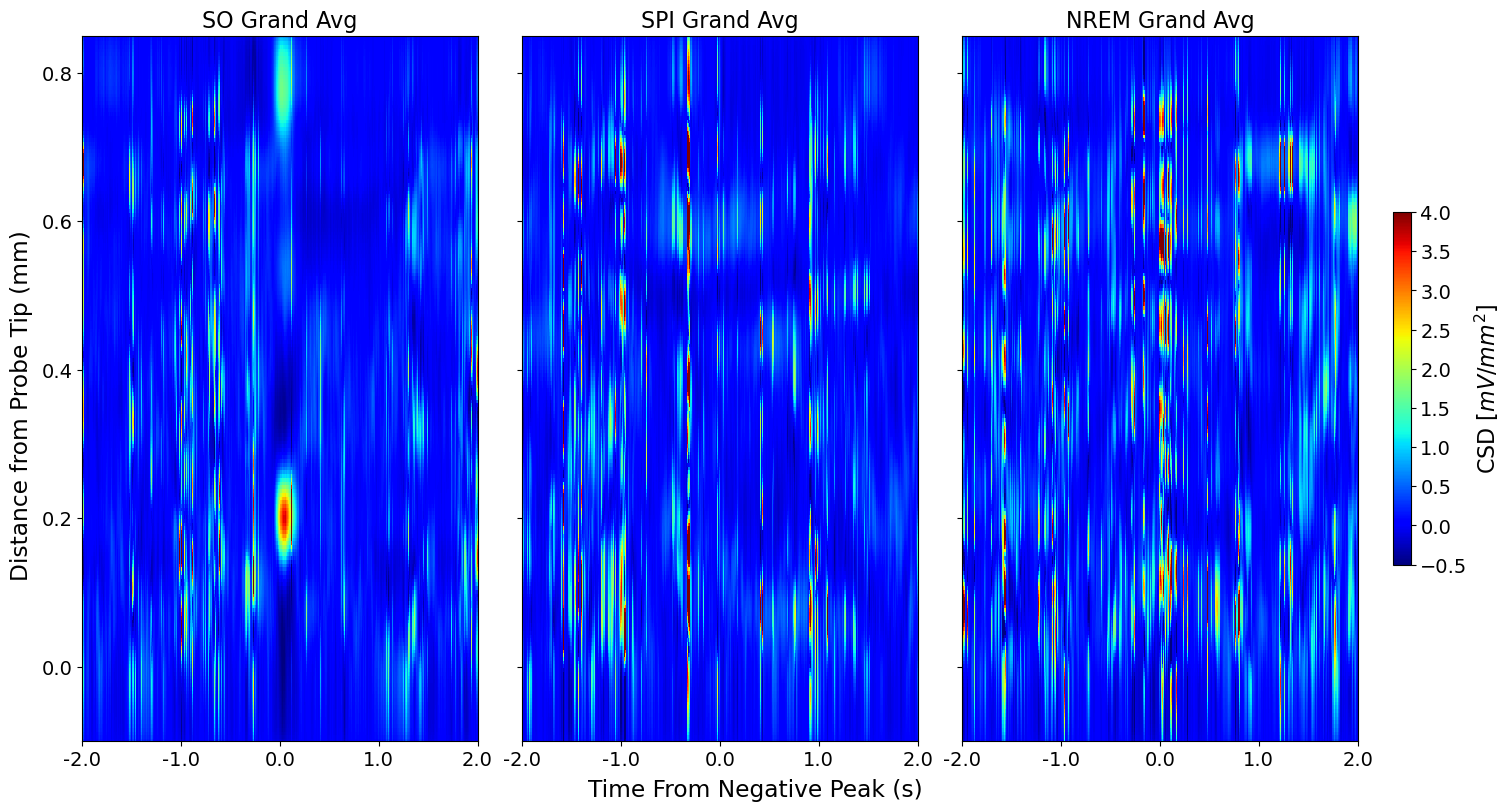

In [ ]:
# x_coords = csd_2D.annotations["x_coords"][:, 0]
# y_coords = csd_2D.annotations["y_coords"][0, :]
title_dict = {
    "so-peak": "SO @ Neg Peak",
    "spi-peak": "SPI @ Neg Peak",
    "nrem-null": "Null Baseline",
}
trig_scale = {
    "so-peak": 1,
    "spi-peak": 1,
    "nrem-null": 1,
}
fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 8),
    constrained_layout=True,
    sharey=True,
    sharex="row",
)
time_slice = slice(-2, 2)
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
for ax, (trig, tmp_csd) in zip(axs.ravel(), trig_csd["2D"].items()):
    all_traces = xr.concat(hyp_filt_traces[trig], dim="epoch")
    n_time = tmp_csd.shape[0]
    tmp_time = (np.arange(n_time) - int((n_time // 5) * 3)) / 250
    h1 = ax.pcolormesh(
        tmp_time,
        tmp_csd.y.values * pq.mm,
        # tmp_csd.mean(axis=1).T,
        tmp_csd.max(dim="x").T - tmp_csd.sel(time=time_slice).mean(dim=["time", "x"]).T,
        # aspect="auto",
        # extent=[0, n_time, 0, 775],
        vmin=-0.5,
        vmax=4.0,
        cmap="jet",
    )
    # ax.axvline(0, color="k", lw=0.5, ls="--")
    # ax2 = ax.twinx()

    # for ch_ind, (ch, tmp_col) in enumerate(
    #     zip(all_traces.channel.values[::-1], colors)
    # ):
    #     mean_trace = all_traces.sel(channel=ch).sel(time=time_slice).mean(dim="epoch")
    #     ax2.plot(
    #         mean_trace.time.values,
    #         (mean_trace.values.flatten() * trig_scale[trig]) + ch_ind * 7,
    #         color="r",
    #         lw=0.7,
    #     )
    # ax2.tick_params(axis="y", labelright=False, right=False)
    ax.set_xticks(
        (np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
        labels=(np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
    )
    ax.set_title(f"{trig.split("-")[0].upper()} Grand Avg")
cbar = fig.colorbar(
    h1,
    ax=axs[-1],
    shrink=0.5,
    label=f"CSD [$mV/mm^{2}$]",  # ticks=[-0.3, -0.15, 0.0, 0.15, 0.3]
)
# axs[1].set_xlabel("time from negative peak (s)")
axs[0].set_xlim([time_slice.start, time_slice.stop])
# print(axs[0].get_ylim())
axs[0].set_ylim([-0.1, 0.85])

# for ax, (trig, tmp_csd) in zip(axs[1, :].ravel(), trig_csd["2D"].items()):

#     h2 = ax.pcolormesh(
#         tmp_csd.x.values * pq.mm,
#         tmp_csd.y.values * pq.mm,
#         tmp_csd.sel(time=0).T - tmp_csd.sel(time=slice(-3, -2)).mean(dim="time").T,
#         # aspect="auto",
#         # extent=[-25, 100, -100, 850],
#         # vmin=-0.5,
#         # vmax=0.5,
#         cmap="jet",
#     )
#     # ax.set_xticks(np.arange(0, 60, 10), labels=(np.arange(0, 60, 10)))
#     ax.set_title(f"{title_dict[trig]} Grand Avg")
# # axs[1, 0].set_xlim([-1, 1])
# cbar = fig.colorbar(
#     h2,
#     ax=axs[-1],
#     shrink=0.5,
#     label="CSD ",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
# )

fig.supylabel("Distance from Probe Tip (mm)")
fig.supxlabel("Time From Negative Peak (s)")
fig.savefig(
    Path(
        "/gpfs01/born/animal/DanielG/hypo_sleep/figures/csd_2D_grand_avg_.png",  # traces_new.png"
    ),
    dpi=500,
    facecolor="white",
    transparent=False,
    bbox_inches="tight",
)

Text(0.5, 0.01, 'Lateral Distance (mm)')

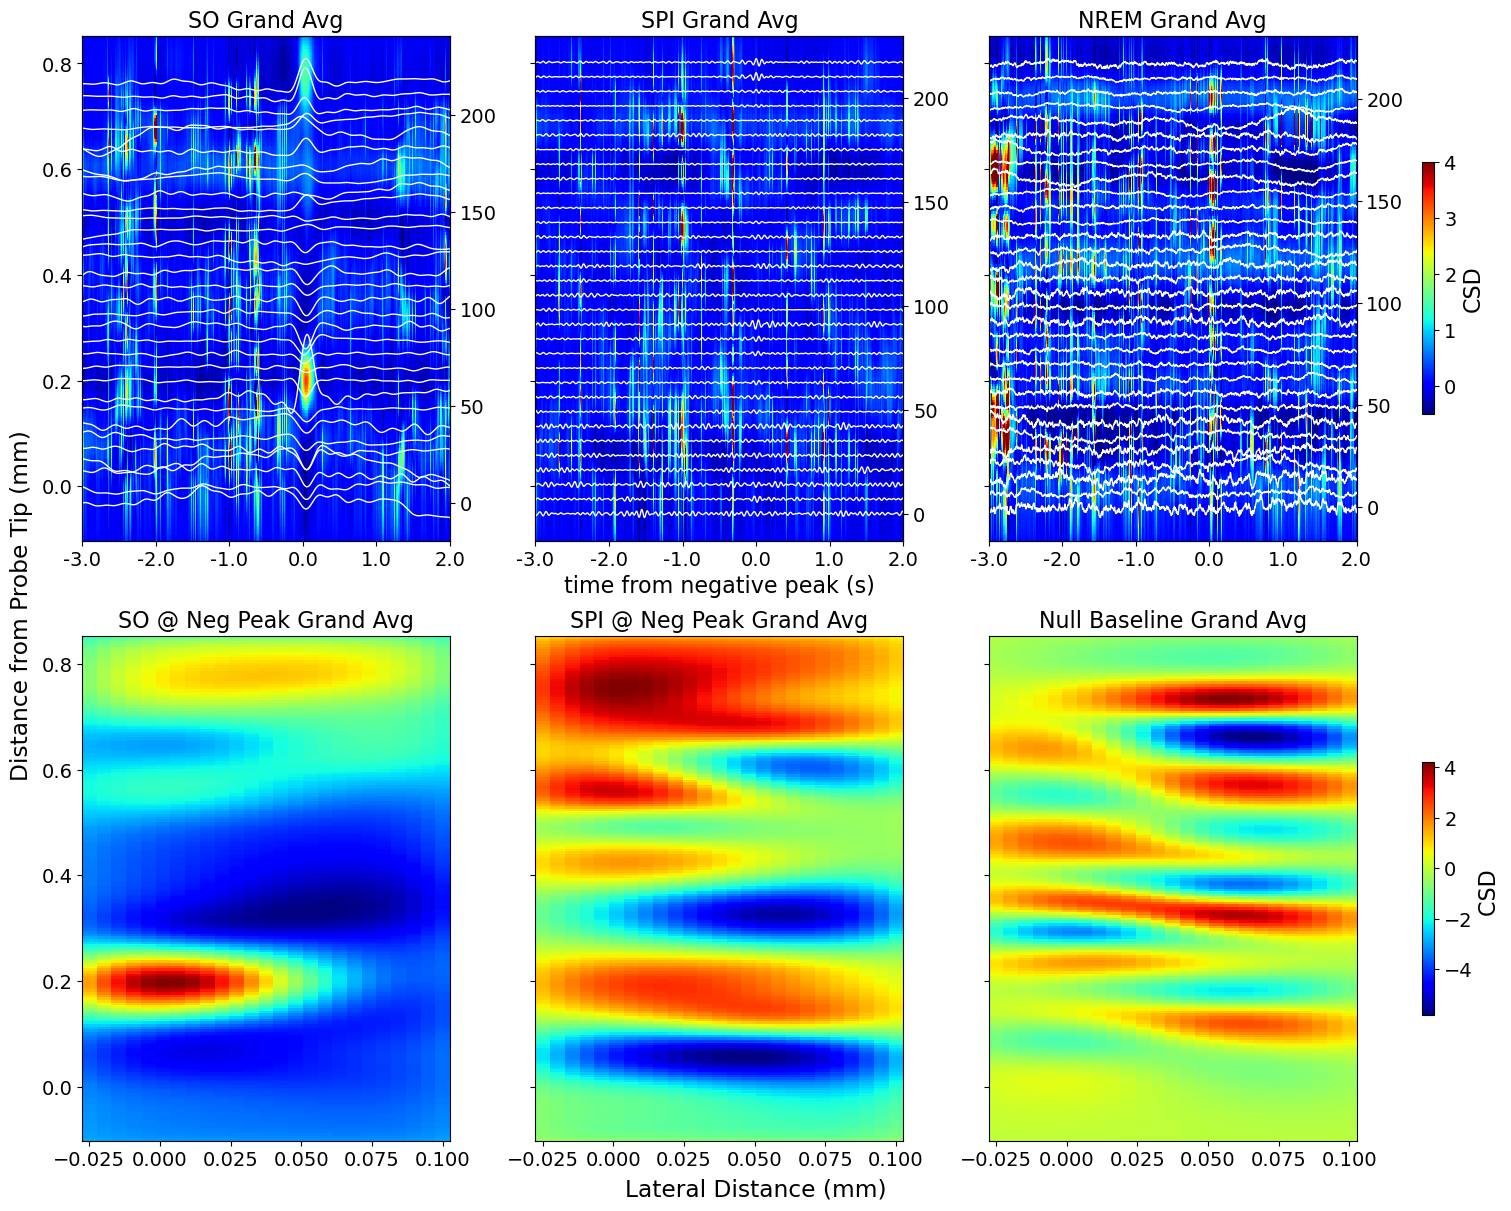

In [52]:
# x_coords = csd_2D.annotations["x_coords"][:, 0]
# y_coords = csd_2D.annotations["y_coords"][0, :]
title_dict = {
    "so-peak": "SO @ Neg Peak",
    "spi-peak": "SPI @ Neg Peak",
    "nrem-null": "Null Baseline",
}
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 12),
    constrained_layout=True,
    sharey=True,
    sharex="row",
)
colors = plt.cm.jet(np.linspace(0, 1, len(depth_ordered_chs)))
for ax, (trig, tmp_csd) in zip(axs[0, :].ravel(), trig_csd["2D"].items()):
    all_traces = xr.concat(hyp_filt_traces[trig], dim="epoch")
    n_time = tmp_csd.shape[0]
    tmp_time = (np.arange(n_time) - int((n_time // 5) * 3)) / 250
    h1 = ax.pcolormesh(
        tmp_time,
        tmp_csd.y.values * pq.mm,
        # tmp_csd.mean(axis=1).T,
        tmp_csd.max(dim="x").T
        - tmp_csd.sel(time=slice(-3, -2)).mean(dim=["time", "x"]).T,
        # aspect="auto",
        # extent=[0, n_time, 0, 775],
        vmin=-0.5,
        vmax=4.0,
        cmap="jet",
    )
    ax2 = ax.twinx()

    for ch_ind, (ch, tmp_col) in enumerate(
        zip(all_traces.channel.values[::-1], colors)
    ):
        mean_trace = all_traces.sel(channel=ch).sel(time=slice(-3, 2)).mean(dim="epoch")
        ax2.plot(
            mean_trace.time.values,
            mean_trace.values.flatten() + ch_ind * 7,
            color="w",
            lw=1,
        )
    ax.set_xticks(
        (np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
        labels=(np.arange(0, n_time, 250) - int((n_time // 5) * 3)) / 250,
    )
    ax.set_title(f"{trig.split("-")[0].upper()} Grand Avg")
cbar = fig.colorbar(
    h1,
    ax=axs[0, -1],
    shrink=0.5,
    label="CSD",  # ticks=[-0.3, -0.15, 0.0, 0.15, 0.3]
)
axs[0, 1].set_xlabel("time from negative peak (s)")
axs[0, 0].set_xlim([-3, 2])

for ax, (trig, tmp_csd) in zip(axs[1, :].ravel(), trig_csd["2D"].items()):

    h2 = ax.pcolormesh(
        tmp_csd.x.values * pq.mm,
        tmp_csd.y.values * pq.mm,
        tmp_csd.sel(time=0).T - tmp_csd.sel(time=slice(-3, -2)).mean(dim="time").T,
        # aspect="auto",
        # extent=[-25, 100, -100, 850],
        # vmin=-0.5,
        # vmax=0.5,
        cmap="jet",
    )
    # ax.set_xticks(np.arange(0, 60, 10), labels=(np.arange(0, 60, 10)))
    ax.set_title(f"{title_dict[trig]} Grand Avg")
# axs[1, 0].set_xlim([-1, 1])
cbar = fig.colorbar(
    h2,
    ax=axs[1, -1],
    shrink=0.5,
    label="CSD ",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)

fig.supylabel("Distance from Probe Tip (mm)")
fig.supxlabel("Lateral Distance (mm)")
# fig.savefig(
#     Path("/gpfs01/born/animal/DanielG/hypo_sleep/figures/csd_2D_grand_avg_traces.png"),
#     dpi=500,
#     facecolor="white",
#     transparent=False,
#     bbox_inches="tight",
# )

In [8]:
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from hmmlearn.hmm import GMMHMM


def vectorize_epochs(epochs):
    """Convert (N, T, H, W) -> (N, T, H*W) or pass through (N, T, C)."""
    if epochs.ndim == 4:
        N, T, H, W = epochs.shape
        return epochs.reshape(N, T, H * W), (H, W)
    elif epochs.ndim == 3:
        return epochs, None
    else:
        raise ValueError("epochs must be 3D or 4D array")


def baseline_subtract(epochs, baseline_slice):
    """Subtract mean over baseline_slice (tuple or slice) per epoch/channel."""
    # baseline_slice: e.g., slice(0, 50) or (start, end)
    if isinstance(baseline_slice, tuple):
        sl = slice(baseline_slice[0], baseline_slice[1])
    else:
        sl = baseline_slice
    base = epochs[:, sl, :].mean(axis=1, keepdims=True)  # (N,1,C)
    return epochs - base


def fit_pca(epochs_vec, n_pcs):
    """Fit PCA on (N*T, C) and return transformed (N, T, n_pcs) and pca object."""
    N, T, C = epochs_vec.shape
    X = epochs_vec.reshape(N * T, C)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    pca = PCA(n_components=min(n_pcs, C), svd_solver="auto")
    Xp = pca.fit_transform(Xs).reshape(N, T, -1)
    return Xp, pca, scaler


# ---------------------------
# HMM-GMM fitting & selection
# ---------------------------
def fit_gmm_hmm(
    X_epochs, n_states=4, n_mix=2, cov_type="diag", n_iter=200, random_state=0
):
    """
    X_epochs: (N, T, D) preprocessed (e.g., PCA-reduced) data.
    Returns fitted GMMHMM and per-epoch decoded state sequences & posteriors.
    """
    N, T, D = X_epochs.shape
    # concatenate for hmmlearn; also lengths array
    Xcat = X_epochs.reshape(N * T, D)
    lengths = [T] * N

    model = GMMHMM(
        n_components=n_states,
        n_mix=n_mix,
        covariance_type=cov_type,
        n_iter=n_iter,
        random_state=random_state,
        verbose=False,
    )
    # init params: use kmeans-like initialization (default is fine, but we can set means_init)
    model.fit(Xcat, lengths)
    # decode states per epoch (Viterbi)
    logprob, states = model.decode(Xcat, lengths=lengths)
    states = states.reshape(N, T)
    # posterior prob per timepoint
    posteriors = model.predict_proba(
        Xcat
    )  # shape (N*T, n_states*n_mix)?? hmmlearn's predict_proba returns per-state mixture probs
    # For GMMHMM, predict_proba returns responsibilities for each HMM state (summing to 1) if I recall.
    # In practice we will use model.predict_proba on per-timepoint to get state posterior:
    state_post = model.predict_proba(Xcat).reshape(N, T, -1)  # (N, T, n_states)
    return model, states, state_post, logprob


def heldout_loglik_cv(
    X_epochs,
    n_states_list,
    n_mix_list,
    n_splits=5,
    random_state=0,
    n_pcs_for_search=None,
):
    """
    Grid-search over n_states_list x n_mix_list using KFold over epochs,
    returning mean held-out log-likelihood for each combo.
    """
    results = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    N, T, D = X_epochs.shape

    for n_states in n_states_list:
        for n_mix in n_mix_list:
            ll_scores = []
            for train_idx, test_idx in kf.split(np.arange(N)):
                X_train = X_epochs[train_idx]
                X_test = X_epochs[test_idx]
                # Fit on train
                model, _, _, _ = fit_gmm_hmm(
                    X_train, n_states=n_states, n_mix=n_mix, random_state=random_state
                )
                # compute log-likelihood on held-out by summing per-sequence score
                Xtest_cat = X_test.reshape(len(test_idx) * T, D)
                lengths_test = [T] * len(test_idx)
                ll = model.score(Xtest_cat, lengths=lengths_test)
                ll_scores.append(ll)
            mean_ll = np.mean(ll_scores)
            results.append({"n_states": n_states, "n_mix": n_mix, "mean_ll": mean_ll})
            print(
                f"n_states={n_states}, n_mix={n_mix} -> mean held-out LL: {mean_ll:.2f}"
            )
    return results


# ---------------------------
# Map state means back to original CSD space
# ---------------------------
def get_state_means_in_original_space(model, pca, scaler, orig_shape=None):
    """
    model: fitted GMMHMM
    pca: fitted PCA object
    scaler: fitted StandardScaler
    orig_shape: (H,W) or None
    Returns: state_mean_maps: shape (n_states, C) or (n_states, H, W) if orig_shape given.
    """
    n_states = model.n_components
    n_mix = model.n_mix
    # hmmlearn GMMHMM stores means_ shape (n_states, n_mix, n_features)
    # For each state, we can compute the weighted mean across mixture components using model.weights_ (shape (n_states, n_mix))
    state_means_pca = np.zeros((n_states, pca.n_components_))
    for s in range(n_states):
        # mixture weights for this state:
        w = model.weights_[s]  # shape (n_mix,)
        mus = model.means_[s]  # shape (n_mix, n_features)
        state_means_pca[s] = np.sum(w[:, None] * mus, axis=0)
    # inverse transform: PCA -> scaled original space -> undo scaler
    state_means_scaled = pca.inverse_transform(
        state_means_pca
    )  # back to scaled original feature space
    state_means_orig = scaler.inverse_transform(state_means_scaled)
    if orig_shape is not None:
        H, W = orig_shape
        return state_means_orig.reshape(n_states, H, W)
    else:
        return state_means_orig  # shape (n_states, n_chan)

In [11]:
trig_csd["2D"]["so-peak"].shape

(1001, 100, 99)

In [ ]:
# Demo: create fake data (replace with your epoch-averaged CSD)
N, T, H, W = 60, 200, 8, 8
rng = np.random.RandomState(42)
# Make 3 underlying spatial states that switch over time in each epoch
true_states = rng.randint(0, 3, size=(N, T))
base_maps = rng.normal(0, 1, size=(3, H, W)) * np.array([1.0, -1.5, 0.7])[:, None, None]
epochs = np.zeros((N, T, H, W))
for i in range(N):
    for t in range(T):
        s = true_states[i, t]
        epochs[i, t] = base_maps[s] + 0.1 * rng.normal(size=(H, W))

# vectorize and baseline subtract
epochs_vec, orig_shape = vectorize_epochs(epochs)
epochs_vec = baseline_subtract(epochs_vec, baseline_slice=slice(0, 20))

n_pcs = 20
Xp, pca, scaler = fit_pca(epochs_vec, n_pcs)

# Quick grid search (coarse) for n_states, n_mix
n_states_list = [2, 3, 4]
n_mix_list = [1, 2]
results = heldout_loglik_cv(Xp, n_states_list, n_mix_list, n_splits=4, random_state=1)

# Choose best (highest mean_ll)
best = max(results, key=lambda r: r["mean_ll"])
print("Best:", best)
n_states_best, n_mix_best = best["n_states"], best["n_mix"]

# Fit final model on all epochs
model, states, state_post, final_ll = fit_gmm_hmm(
    Xp, n_states=n_states_best, n_mix=n_mix_best, n_iter=300, random_state=2
)
print("Final model log-likelihood (training):", final_ll)

# Map state means back to grid
state_maps = get_state_means_in_original_space(
    model, pca, scaler, orig_shape=orig_shape
)

# Plot state mean maps
K = state_maps.shape[0]
fig, axs = plt.subplots(1, K, figsize=(3 * K, 3))
for k in range(K):
    axs[k].imshow(state_maps[k], origin="lower")
    axs[k].set_title(f"State {k}")
    axs[k].axis("off")
plt.show()

# Plot state occupancy (mean posterior across epochs)
mean_post = state_post.mean(axis=0).mean(axis=0)  # careful: state_post shape (N, T, K)
# Actually our state_post was (N, T, K) already, so:
mean_post_time = state_post.mean(axis=0)  # (T, K) average across epochs
plt.figure()
for k in range(K):
    plt.plot(mean_post_time[:, k], label=f"State {k}")
plt.xlabel("time")
plt.ylabel("mean posterior probability")
plt.legend()
plt.show()

# Example: show decoded states raster for first 10 epochs
plt.figure(figsize=(8, 4))
plt.imshow(states[:10], aspect="auto", interpolation="nearest")
plt.xlabel("time")
plt.ylabel("epoch")
plt.title("Viterbi-decoded state per time, first 10 epochs")
plt.colorbar(label="state")
plt.show()

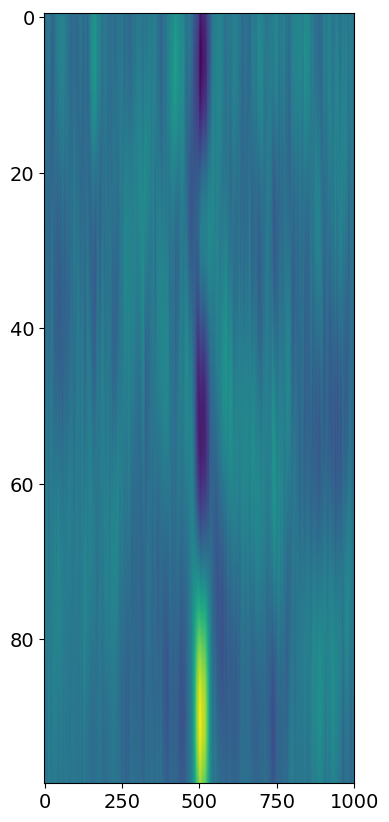

In [8]:
fig, ax = plt.subplots(figsize=(4, 10))
ax.imshow(trig_csd["2D"]["so-peak"].mean(axis=1).T, aspect="auto")

In [ ]:
from sklearn.mixture import BayesianGaussianMixture

X = np.array(tmp_csd).mean(axis=1)
bgm = BayesianGaussianMixture(
    n_components=10,
    random_state=42,
    n_init=100,
).fit(X)

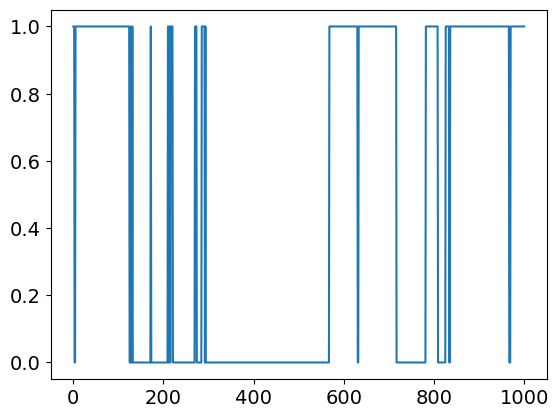

In [18]:
plt.plot(bgm.predict(X))

In [ ]:
np.array(tmp_csd).mean(axis=1)

(99, 1001)

Text(0.5, 0.01, 'Lateral Distance (µm)')

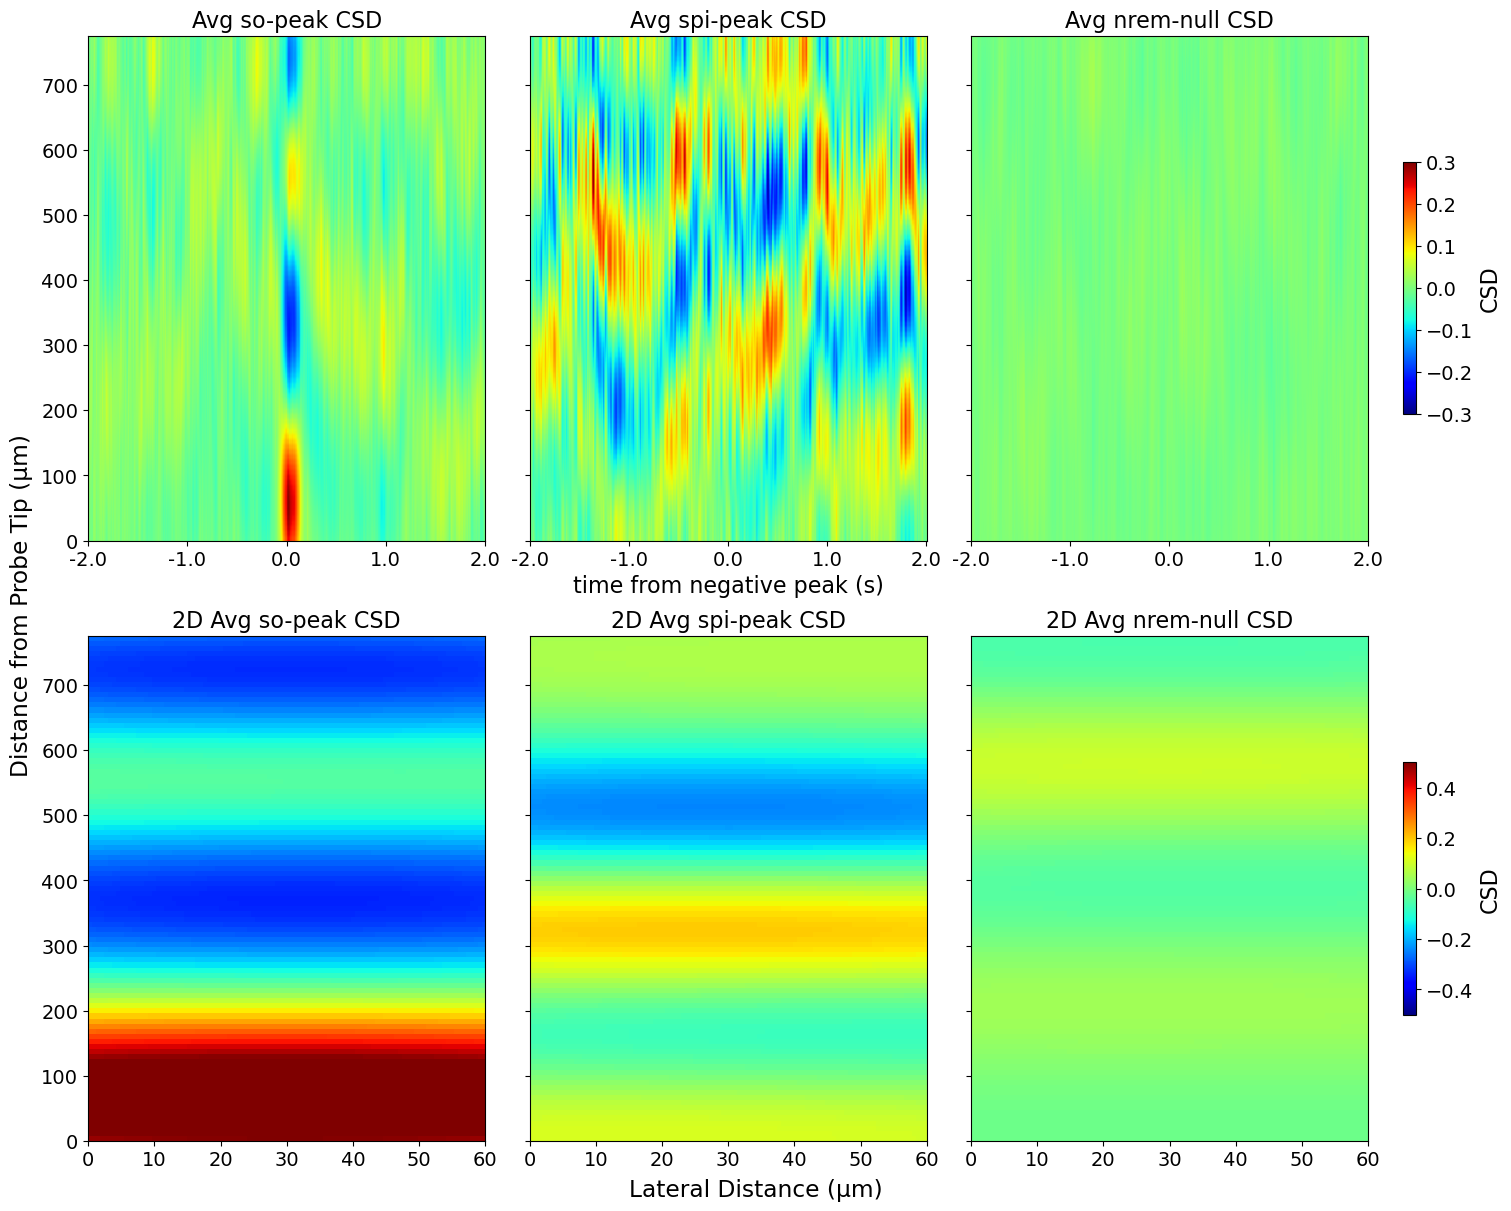

In [ ]:
fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 12),
    constrained_layout=True,
    sharey=True,
)
for ax, (trig, tmp_csd) in zip(axs[0, :].ravel(), trig_csd["1D"].items()):

    h1 = ax.imshow(
        np.array(tmp_csd).T,
        aspect="auto",
        extent=[0, 1001, 0, 775],
        vmin=-0.3,
        vmax=0.3,
        cmap="jet",
    )
    ax.set_xticks(np.arange(0, 1001, 250), labels=(np.arange(0, 1001, 250) - 500) / 250)
    ax.set_title(f"Avg {trig} CSD")
cbar = fig.colorbar(
    h1,
    ax=axs[0, -1],
    shrink=0.5,
    label="CSD",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)
axs[0, 1].set_xlabel("time from negative peak (s)")

for ax, (trig, tmp_csd) in zip(axs[1, :].ravel(), trig_csd["2D"].items()):

    h2 = ax.imshow(
        np.array(tmp_csd)[500, :, :].T,
        aspect="auto",
        extent=[0, 60, 0, 775],
        vmin=-0.5,
        vmax=0.5,
        cmap="jet",
    )
    # ax.set_xticks(np.arange(0, 60, 10), labels=(np.arange(0, 60, 10)))
    ax.set_title(f"2D Avg {trig} CSD")
cbar = fig.colorbar(
    h2,
    ax=axs[1, -1],
    shrink=0.5,
    label="CSD",  # ticks=[-0.5, -0.25, 0.0, 0.25, 0.5]
)
fig.supylabel("Distance from Probe Tip (µm)")
fig.supxlabel("Lateral Distance (µm)")

In [57]:
full_traces = xr.concat(traces, dim=pd.Index(channels, name="channel"))

In [70]:
full_traces.set_xindex("start_state").sel(start_state="NREM").trial.values

array([ 1,  2,  3,  4,  6,  7,  9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
       21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 37, 38, 40, 41, 44,
       47, 52, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69,
       70, 71, 72, 74, 75, 76, 79, 80, 81, 82])

In [91]:
time_span = (
    np.arange(int(params.get("spectra_window", 2) * params.get("Fs", 250)) * 2 + 1)
    - int(params.get("spectra_window", 2) * params.get("Fs", 250))
) / params.get("Fs", 250)
traces = []
for ch in depth_ordered_chs[::-1]:
    if str(ch) in rec.get_channel_ids():
        chunk_traces = []
        for chunk_ind, (start, stop) in enumerate(chunks):
            if start - 0.05 < rec.get_start_time():
                chunk_remove.append(chunk_ind)
                continue
            if stop - start < params.get("spectra_window", 1):
                chunk_remove.append(chunk_ind)
                if params.get("verbose", False):
                    logger.info(
                        f"Skipping chunk {start}-{stop} for channel {ch} due to insufficient length."
                    )
                continue
            if stop + 0.05 > rec.get_end_time():
                chunk_remove.append(chunk_ind)
                if params.get("verbose", False):
                    logger.info(
                        f"skipping chunk with stop: {stop:.02f} for channel {ch}. Recording is only {rec.get_end_time():.02f}s long."
                    )
                continue
            tmp_rec = rec.time_slice(
                start_time=start - 0.05,
                end_time=stop + 0.05,
            )
            tmp_trace = tmp_rec.get_traces(channel_ids=[ch], return_in_uV=True)
            half_arr_size = tmp_trace.flatten().size // 2
            offset = half_arr_size - int(
                params.get("spectra_window", 2) * params.get("Fs", 250)
            )
            chunk_traces.append(
                xr.DataArray.from_dict(
                    {
                        "data": tmp_trace.flatten()[offset:-offset],
                        "dims": "time",
                        "coords": {"time": {"dims": "time", "data": time_span}},
                        "name": f"{ch}",
                    }
                )
            )
        traces.append(xr.concat(chunk_traces, dim="trial"))
full_traces = xr.concat(traces, dim="channel")
full_traces.name = "depth-ordered"

In [93]:
full_traces

<xarray.DataArray 'depth-ordered' (channel: 32, trial: 3069, time: 1001)> Size: 393MB
array([[[ 5.18986473e+01,  5.50651245e+01,  7.63878403e+01, ...,
         -5.37283182e+00, -1.94579639e+01, -3.37075710e+00],
        [-4.33894043e+01, -2.17765884e+01, -4.57166672e+00, ...,
          2.65554714e+01,  3.53694725e+01,  4.27618752e+01],
        [ 7.30024109e+01,  4.56238441e+01,  5.59667282e+01, ...,
         -6.43266449e+01, -4.85229225e+01, -4.69066963e+01],
        ...,
        [ 1.42009010e+01,  1.61265755e+01, -8.74870718e-01, ...,
         -2.61857796e+01, -2.07748852e+01, -3.79504471e+01],
        [-8.33339691e+01, -7.72915115e+01, -7.55480423e+01, ...,
         -1.16928005e+01, -5.83253145e+00, -9.57144165e+00],
        [-3.10011406e+01, -2.41017380e+01, -3.44839897e+01, ...,
         -1.92974606e+01, -3.12401581e+01, -3.59051208e+01]],

       [[ 3.34197593e+00, -6.88319397e+00,  1.38868771e+01, ...,
         -1.53634949e+01, -1.19774637e+01,  4.36765957e+00],
        [-2.70625591e+01,  9.06829387e-02,  1.34269981e+01, ...,
         -4.19583321e+00, -1.13687773e+01, -9.99072742e+00],
        [ 7.06582413e+01,  7.95319138e+01,  7.91527557e+01, ...,
         -1.09858913e+01, -2.12020855e+01, -2.38933601e+01],
...
          4.63746529e+01,  4.98983498e+01,  2.37458458e+01],
        [-6.71402645e+00,  4.12427306e-01,  7.03901978e+01, ...,
          3.61158991e+00,  2.11799850e+01,  2.55557728e+01],
        [ 3.62048073e+01, -2.47677460e+01, -3.04817410e+01, ...,
         -6.59008942e+01, -1.12244438e+02, -1.31602112e+02]],

       [[ 3.88873076e+00, -9.38753986e+00, -2.03099206e-01, ...,
         -1.51727724e+01, -2.03113194e+01, -2.09064293e+01],
        [ 3.91492195e+01,  3.12336407e+01,  2.93529530e+01, ...,
          9.78806496e+00,  3.30647545e+01,  2.71256886e+01],
        [-2.38617592e+01, -5.57340670e+00, -1.19786339e+01, ...,
          1.12187634e+01,  8.91619444e-01, -2.38249227e-01],
        ...,
        [-9.51258469e+00,  1.23239636e+00, -3.80012417e+00, ...,
         -1.98336277e+01, -1.19439268e+01,  1.55649269e+00],
        [-7.72987747e+01, -1.25982231e+02, -1.33509232e+02, ...,
         -7.86126633e+01, -1.12131905e+02, -5.64637184e+01],
        [ 6.52637625e+00,  7.06893778e+00,  3.51839561e+01, ...,
         -1.83117046e+01, -2.85401592e+01,  3.64183688e+00]]],
      shape=(32, 3069, 1001), dtype=float32)
Coordinates:
  * time     (time) float64 8kB -2.0 -1.996 -1.992 -1.988 ... 1.992 1.996 2.0
Dimensions without coordinates: channel, trial